# Session 6: Modeling and Evaluation

This session covers the fundamentals of model building and evaluation techniques for predictive analytics. We'll explore how to properly setup an experimental design, discuss bias-variance trade-off, and go over key performance metrics for model comparison.

In [6]:
#ONLY FOR GOOGLE COLAB

# Code to access drive
from google.colab import drive
drive.mount('/content/drive')

# Set working directory to proper location
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/Data Analytics/Session 6")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Experimental Setup

The first step in any predictive model is establishing a proper experimental setup. We always want to understand how well our model will perform in real-world situations, ideally **before** we deploy it, rather than getting an unpleasant surprise later.

**The fundamental principle:** Model evaluation must always be done on **unseen** data. Evaluating your model on the same data used for training is like a self-fulfilling prophecy: you'll likely be correct because you're testing patterns on the exact same data where you learned those patterns.

**Example:** If all elderly customers in your training data churned, your model will always predict elderly customers as churners. But is this the true relationship? Only unseen data can validate whether learned patterns generalize beyond the training sample.

**The solution:** Divide your data into separate chunks: some for **learning** patterns and others for **evaluating** performance. While this principle is straightforward, several methods exist for creating these learning and evaluation splits.

For this session, we'll use a focused **churn** dataset with **RFM** (Recency, Frequency, Monetary) and **LOR** (Length of Relationship) variables. This is a more compact dataset compared to the preprocessing section, designed specifically for modeling exercises with sufficient data points for robust evaluation.  

In [1]:
import pandas as pd
import numpy as np

# Load the churn dataset
basetable = pd.read_csv('./Data/basetable.csv')

# Quick data overview
print(f"Dataset shape: {basetable.shape}")
print(f"\nColumn types:\n{basetable.dtypes}")
print(f"\nFirst few rows:")
basetable.head()

Dataset shape: (41739, 5)

Column types:
Monetary_score    float64
Total_quantity      int64
recency_score       int64
days_customer       int64
churn               int64
dtype: object

First few rows:


,Monetary_score,Total_quantity,recency_score,days_customer,churn
0,12519.0,715,16,15503,0
1,7315.2,309,36,16964,0
2,3267.8,176,15,22442,0
3,1289.0,74,21,16598,0
4,6789.0,390,1,15137,0


Now that we understand why unseen data is crucial, how do we actually obtain it? The most common approach is to divide your available data into chunks for model building and evaluation. Several methods exist for creating these splits, but the two most common sampling strategies are:
- **Holdout set**: Simple train/test division
- **Cross-validation**: Multiple train/test splits for more robust evaluation.

Ideally, the binary churn variable should be in integer or category format for our models to recognize this as a classifcation task, which is already the case. To make our sampling easier later on, we will seperate the X and y variables.

In [2]:
# Separate features (X) and target (y)
X = basetable.drop('churn', axis=1)
y = basetable['churn']

print(f"Features shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features shape: (41739, 4)
Target distribution: {0: 40166, 1: 1573}


### The Holdout Set

#### Train/Test

We start with the simplest implementation: dividing data into one **training set** and one **test set**.

We'll use a **60/40 split** (60% training, 40% testing). This puts somewhat more data in the training set since more training data generally leads to better model performance, while still keeping enough test set observations for reliable evaluation. While 70/30 is also common, I prefer a more equal split to ensure robust testing.

Before splitting, we need to understand **reproducibility**. Machine learning involves randomness (shuffling data, initializing models), but for learning and debugging, we want consistent results. Setting a random state (seed) ensures everyone gets the same "random" split.

In [3]:
from sklearn.model_selection import train_test_split

# Set random state for reproducibility
# This ensures everyone gets the same "random" split for consistent results
RANDOM_STATE = 123

# 60/40 train-test split (60% for training, 40% for testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y  # Ensures both sets have same proportion of churn/non-churn
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Training churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")

Training set: 25043 samples (60.0%)
Test set: 16696 samples (40.0%)
Training churn rate: 0.038
Test churn rate: 0.038


#### Train/Validation/Test

When comparing different models or parameter settings, we need a **validation set** to avoid overfitting to the test set. If we evaluate multiple models on the test set (also called test set torturing), we risk selecting the model that performs best on that specific test set, rather than one that truly generalizes well.

To solve this, we create three splits: train (for learning), validation (for model tuning), and test (for final model evaluation).

We'll use a **60/20/20 split** (60% training, 20% validation, 20% testing). This maintains a substantial training set while providing equal-sized validation and test sets for robust evaluation.

In Python, creating a three-way split requires two calls to `train_test_split()`. First, we split into temporary (80%) and test (20%). Then we split the temporary data into train (75% of 80% = 60% of total) and validation (25% of 80% = 20% of total).

In [4]:
# Create three-way split: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 of 0.8 = 0.2 of total
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set: 25043 samples (60.0%)
Validation set: 8348 samples (20.0%)
Test set: 8348 samples (20.0%)


#### Model Comparison Example

Let's demonstrate the three-set approach with a practical example using **K-Nearest Neighbors (KNN)**.

**KNN**

This is an intuitive algorithm that classifies customers based on their similarity to others. For each new customer in the validation or test set, it finds the K most similar customers (based on the Euclidean distance) in the training data and predicts based on their majority class. For example, if K=5 and 4 of the 5 nearest neighbors churned, the model predicts churn. We'll test different values of K to find the optimal number of neighbors. In machine learning, K is called a **hyperparameter** since it determines the model’s behavior but is not learned directly from the data like model parameters.

Some important notes about the modeling process
- Since KNN relies on Euclidean distances, all features must be on the same scale to avoid bias toward variables with larger ranges. The most reliable way to ensure this is to use a **pipeline** that first standardizes the data and then fits the KNN model, so the same scaling is applied consistently applied both all different sets.
- We will use the `predict_proba()` to output the prediction scores and compute the AUC to select the best value of K (explained later more in detail).


K= 3: Validation AUC = 0.6056
K= 5: Validation AUC = 0.6307
K=10: Validation AUC = 0.6579
K=15: Validation AUC = 0.6783
K=20: Validation AUC = 0.6912
K=30: Validation AUC = 0.7222
K=50: Validation AUC = 0.7377


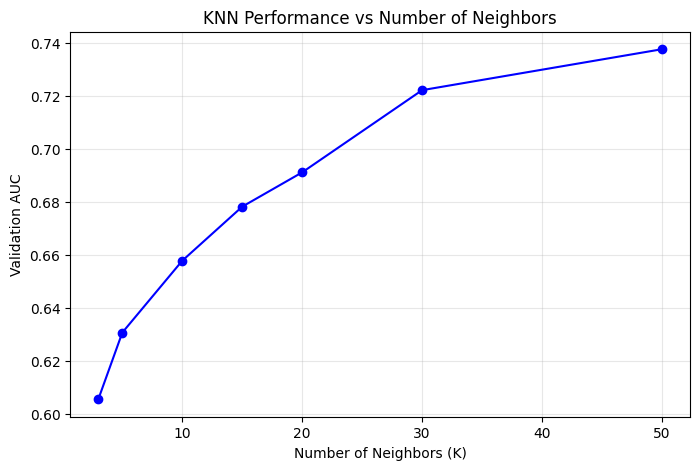

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Test different numbers of neighbors
k_values = [3, 5, 10, 15, 20, 30, 50]
validation_scores = []

# Create a pipeline that scales features and fits KNN
# Scaling is crucial for KNN since it uses distance calculations
for k in k_values:
    # Pipeline: Scale features → Fit KNN
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])

    # Fit on training data
    pipeline.fit(X_train, y_train)

    # Predict probabilities on validation set
    val_probs = pipeline.predict_proba(X_val)[:, 1]  # Probability of churn (class 1)

    # Calculate AUC score
    auc_score = roc_auc_score(y_val, val_probs)
    validation_scores.append(auc_score)

    print(f"K={k:2d}: Validation AUC = {auc_score:.4f}")

# Visualize results
plt.figure(figsize=(8, 5))
plt.plot(k_values, validation_scores, 'bo-')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Validation AUC')
plt.title('KNN Performance vs Number of Neighbors')
plt.grid(True, alpha=0.3)
plt.show()

#### Final Model Training and Evaluation

Once we identify the best hyperparameter, we **combine** training and validation data for final model training. The main idea is that all available data typically improves model performance.

The test set gives us an unbiased estimate of how the model will perform on unseen data. You will notice small differences between validation and test performance. They reflect natural variation between different data splits.

In [6]:
# Find best parameter
best_k = k_values[np.argmax(validation_scores)]
best_val_score = max(validation_scores)

print(f"Best parameter: K = {best_k}")
print(f"Best validation AUC: {best_val_score:.4f}")

# Combine training and validation data
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Train final model with best parameter on all available training data
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=best_k))
])

final_pipeline.fit(X_train_full, y_train_full)

# Evaluate on test set (first and only time!)
test_probs = final_pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)

print(f"\nFinal test AUC: {test_auc:.4f}")
print(f"Difference from validation: {test_auc - best_val_score:.4f}")

Best parameter: K = 50
Best validation AUC: 0.7377

Final test AUC: 0.7439
Difference from validation: 0.0062


#### Alternative (and better) approach: GridSearchCV

**GridSearchCV** provides a more robust approach by automatically handling train/validation splitting using **cross-validation**. Instead of creating the train, validation and test split, you just create the initial train and test set as the **outer loop** and then let `GridSearchCV()` do the **inner loop** automatically.

**Workflow:**
1. Manually split data into train (80%) and test (20%)
2. Create the splits for the training-validation sets
3. `GridSearchCV` performs validation split within the training set for hyperparameter tuning
4. Select best hyperparameter based on average cross-validation performance
5. Final evaluation on held-out test set

**Advantages of GridSearchCV:**
- Allows for more sampling approaches (e.g., cross-valdiation is built-in and even easier to do)
- Less code to write and maintain
- Automatically refits on full training data with best parameters (so no retraining)
- Eliminates human error in manual splitting

**Note**: the performance of the validation set are different than in the previous manual split. Do you know why?

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit

# Manual train/test split + GridSearchCV for hyperparameter tuning
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Create pipeline for GridSearch
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

# Define parameter grid
param_grid = {
    'classifier__n_neighbors': [3, 5, 10, 15, 20, 30, 50]
}

# Use ShuffleSplit for a single train/validation split within GridSearch
cv_splitter = ShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv_splitter,  # Single train/validation split
    scoring='roc_auc', # Optimize for AUC
)

# Fit GridSearch on training data (automatically handles train/val splits)
grid_search.fit(X_train, y_train)

print(f"Best parameter: K = {grid_search.best_params_['classifier__n_neighbors']}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

# Evaluate on test set
test_probs_grid = grid_search.predict_proba(X_test)[:, 1] #no retraining needed
test_auc_grid = roc_auc_score(y_test, test_probs_grid)
print(f"Final test AUC: {test_auc_grid:.4f}")

Best parameter: K = 50
Best CV AUC: 0.7470
Final test AUC: 0.7439


### Cross-Validation

The inspiration behind **cross-validation (CV)** is to make performance estimates more reliable by using different test sets and averaging the results, rather than relying on a single random train/test split.

**The process:** Instead of splitting data once, we split it into multiple "folds" and systematically use each fold as a test set while training on the remaining folds. For example:
- **2-fold CV**: Split data in half, use each half once as training and once as test
- **3-fold CV**: Split into 3 parts, always use 2 for training and 1 for testing
- **10-fold CV**: Split into 10 parts, perform 10 different train/test combinations

**10-fold CV** is one of the most popular approaches in machine learning literature. We create 10 equal chunks of data, and each fold uses a different chunk as the test set while training on the remaining 9 chunks.

**Implementation:**
- **Manual approach**: Create loops to split data, fit models, and collect scores for each fold
- **Automated approach**: Use sklearn's `cross_val_score()` function that handles all the splitting and scoring automatically

We'll use the **automated approach** with sklearn's `cross_val_score()` function since it's more reliable, less error-prone, and follows best practices. This function handles all the complex splitting logic internally and is the same approach used by `GridSearchCV`.

#### The Big Outer Loop

Let's demonstrate this with a KNN model with a fixed K=50 to see how performa
nce varies across different data splits. Hence, we are using a **big outer loop** which averages the final performance over the ten folds.

10-Fold Cross-Validation Results (K=50):
----------------------------------------


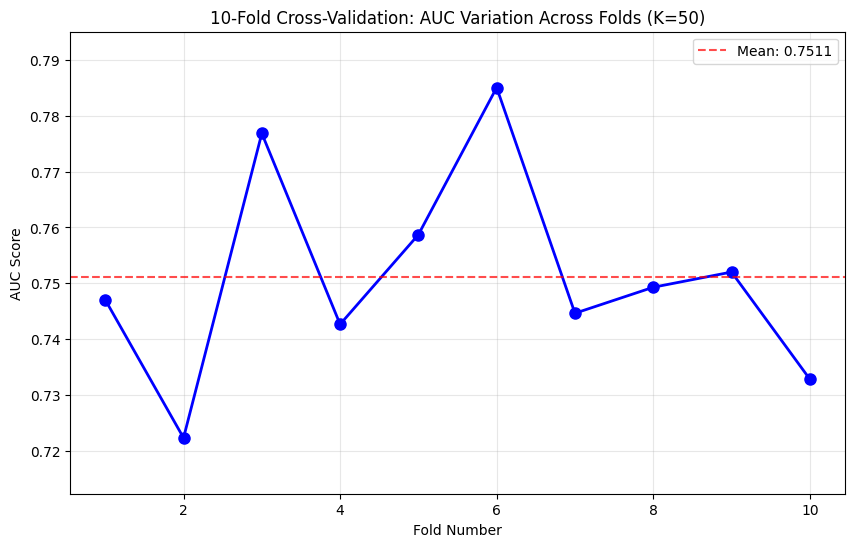


Observation: AUC scores vary from 0.7223 to 0.7850

The average AUC score equals: 0.751133


In [8]:
from sklearn.model_selection import cross_validate, KFold
import matplotlib.pyplot as plt

# 10-fold Cross-Validation with fixed K=50 (no hyperparameter tuning)
# Using sklearn's automated cross_validate function

# Create pipeline with fixed K=10
pipeline_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=50))
])

# Define 10-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

print("10-Fold Cross-Validation Results (K=50):")
print("-" * 40)

# Automated cross-validation with cross_validate
# Pipeline is already created
cv_results = cross_validate(
    pipeline_cv,
    X, y,
    cv=kfold,
    scoring='roc_auc'
)

# Extract test scores for consistency with previous code
cv_scores = cv_results['test_score']

# Get mean AUC score
test_auc_cv = np.mean(cv_scores)

# Visualize the variation across folds
fold_number = list(range(1, 11))
plt.figure(figsize=(10, 6))
plt.plot(fold_number, cv_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=np.mean(cv_scores), color='r', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(cv_scores):.4f}')
plt.xlabel('Fold Number')
plt.ylabel('AUC Score')
plt.title('10-Fold Cross-Validation: AUC Variation Across Folds (K=50)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim([min(cv_scores)-0.01, max(cv_scores)+0.01])
plt.show()

print(f"\nObservation: AUC scores vary from {np.min(cv_scores):.4f} to {np.max(cv_scores):.4f}")
print(f"\nThe average AUC score equals: {np.average(cv_scores):4f}")

This demonstrates why single train/test splits can be unreliable! Using `cross_val_score` is also much simpler than manual loops! It automatically handles the splitting, fitting, and scoring for each fold.

#### The Big Inner Loop: Cross-Validation with Hyperparameter Tuning

Now let's combine the best of both worlds: use a **train/test split** for final model evaluation, and **10-fold cross-validation within GridSearchCV** for robust hyperparameter selection. This is also referred to as the **big inner loop** since we perform extensive hyperparameter tuning within the training set.

**Workflow:**
1. Split data into train (60%) and test (40%) (already done)
2. `GridSearchCV` performs 10-fold cross-validation within the training set
3. Each hyperparameter combination is evaluated across 10 different train/validation splits
4. Select the hyperparameter with the best average performance across all folds
5. Final model evaluation on the held-out test set

This approach gives us both robust hyperparameter selection (through cross-validation) and an unbiased performance estimate (through the untouched hold-out test set).

**Parallel processing:** An important option of GridSearchCV is the `n_jobs` parameter to control parallel processing:
- `n_jobs=1` (default): Uses single CPU core
- `n_jobs=-1`: Uses all available CPU cores for parallel processing
- `n_jobs=N`: Uses N specific number of cores

Setting `n_jobs=-1` can significantly speed up performance when working with larger datasets or extensive hyperparameter grids, as it allows multiple cross-validation folds to be processed simultaneously across different CPU cores.

In [11]:
# Setup and run GridSearchCV with 10-fold cross-validation
# 10-fold cross-validation for hyperparameter tuning
grid_search_10k = GridSearchCV(
    pipeline,
    param_grid,
    cv=kfold,  # 10-fold cross-validation, as defined earlier
    scoring='roc_auc',
    n_jobs=-1,  # Use all available CPU cores for parallel processing
    return_train_score=True  # To see overfitting
)

# Fit GridSearchCV on training data (this will take a moment...)
grid_search_10k.fit(X_train, y_train)

# Get final test set predictions
test_probs_grid_10k = grid_search_10k.predict_proba(X_test)[:, 1]
test_auc_grid_10k = roc_auc_score(y_test, test_probs_grid_10k)

Let's analyze the results of our grid search with 10k cross-validation more in detail and compare with the other methods.

The conclusion is that a **grid search** for the hyperparameters is **superior**, because it:  

1.	Tests multiple hyperparameters using cross-validation
2.	Provides unbiased final evaluation on a hold-out test set
3.	Shows standard deviation across folds for reliability assessment
4.	Automatically selects the best hyperparameter and refits on the full training data.

In [10]:
# Analysis of GridSearchCV results
print("=== GridSearchCV Results Analysis ===")
print(f"\nBest parameter: K = {grid_search_10k.best_params_['classifier__n_neighbors']}")
print(f"Best CV AUC (mean of 10 folds): {grid_search_10k.best_score_:.4f}")

# Show CV results for all parameters
cv_results = pd.DataFrame(grid_search_10k.cv_results_)
print(f"\nCross-validation results for all K values:")
for idx, row in cv_results.iterrows():
    k = row['param_classifier__n_neighbors']
    mean_score = row['mean_test_score']
    std_score = row['std_test_score']
    print(f"K={k:2d}: Mean AUC = {mean_score:.4f} (±{std_score:.4f})")

print(f"\nFinal test AUC: {test_auc_grid_10k:.4f}")

=== GridSearchCV Results Analysis ===

Best parameter: K = 50
Best CV AUC (mean of 10 folds): 0.7471

Cross-validation results for all K values:
K= 3: Mean AUC = 0.6041 (±0.0253)
K= 5: Mean AUC = 0.6281 (±0.0267)
K=10: Mean AUC = 0.6635 (±0.0308)
K=15: Mean AUC = 0.6920 (±0.0294)
K=20: Mean AUC = 0.7045 (±0.0236)
K=30: Mean AUC = 0.7284 (±0.0185)
K=50: Mean AUC = 0.7471 (±0.0085)

Final test AUC: 0.7439


#### Fully Nested Cross-Validation

While our previous approaches have improved in robustness, we can take model evaluation to the next level of rigor with **fully nested cross-validation**. This represents the most methodologically sound approach for obtaining unbiased performance estimates and is considered the gold standard in academic machine learning research.

**The limitation of previous approach**

Even our sophisticated `GridSearchCV` with 10-fold cross-validation still has one potential weakness: it relies on a **single random train/test split** for the final performance evaluation. While this split is held out and never used for hyperparameter tuning, the final performance estimate still depends on this one particular split of the data.

Consider this scenario: What if our specific 80/20 split happened to be particularly favorable (or unfavorable) for our model? The final AUC score would reflect this random variation rather than the model's true generalization capability. Different random splits might yield meaningfully different performance estimates.

**Solution: nested cross-validation**

Fully nested cross-validation eliminates this dependence on any single train/test split by using **cross-validation at two levels**:

1. **Outer loop (performance evaluation)**: Creates multiple independent train/test splits using 10-fold CV
2. **Inner Loop (hyperparameter uuning)**: Within each outer fold's training data, performs 10-fold CV for hyperparameter selection

**Workflow:**

For each of the 10 outer folds:
1. **Split**: Divide data into 10 outer folds
2. **Inner GridSearchCV**: Use the 9 outer folds for training portion to perform 10-fold cross-validation across all hyperparameter combinations
3. **Select Best Hyperparameter**: Choose the hyperparameter with the best average performance across the 10 inner folds  
4. **Final Training**: Retrain the model with the best hyperparameter on the 9 outer folds training data
5. **Evaluation**: Test the final model on the 1 remaining outer fold as holdout test set
6. **Store Score**: Record the AUC score for this outer fold

**The result**: Instead of one performance estimate from one train/test split, we obtain **10 independent performance estimates** from 10 different train/test configurations. This allows us to:
- Calculate a **mean performance** across multiple data splits
- Assess **performance variability** through standard deviation
- Construct **confidence intervals** for more reliable conclusions
- Eliminate bias from any single "lucky" or "unlucky" train/test split

**Attention points:**
- **Computational cost**: 700 model fits (10×10×7) vs 70 fits for single split GridSearchCV
- **Statistical robustness**: Unbiased estimates, confidence intervals, variance assessment
- **Time complexity**: ~10× longer than single-split approach

**Practical guidelines:**
- **Academic research**: Use full nested CV (outer + inner loops) for maximum rigor
- **Industry applications**: Typically use CV in inner loop only (GridSearchCV) for efficiency
- **Rapid prototyping**: Single train/test splits are sufficient for initial exploration

The most robust way to implement this is to combine 10-fold CV in both the outer and inner loops to get fully **nested cross-validation**, which we'll demonstrate next. Two important notes:
1. Since we have already created the outer and cross-validation objects, we dont need to specify them again.
2. The code may take some time to run!

In [11]:
from sklearn.model_selection import cross_validate
import time

# Setup for nested cross-validation
# Record start time
start_time = time.time()

# Perform nested cross-validation
# This uses the already created GridSearchCV for the inner loop
# Tje folds are already defined by kfold
nested_cv_results = cross_validate(
    grid_search_10k,
    X, y,
    cv=kfold,
    scoring='roc_auc',
    n_jobs=1,  # Set to 1 to avoid nested parallelization issues
    return_train_score=True
)

end_time = time.time()

/Users/matthiasbogaert/anaconda3/envs/colabenv25/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [12]:
# Analyze nested cross-validation results
nested_scores = nested_cv_results['test_score']
test_auc_nested = np.mean(nested_scores)

print(f"Computation time: {end_time - start_time:.1f} seconds")
print(f"\n=== Nested Cross-Validation Results ===")
print(f"Mean AUC across 10 outer folds: {np.mean(nested_scores):.4f}")
print(f"Standard deviation: {np.std(nested_scores):.4f}")
print(f"95% Confidence interval: [{np.mean(nested_scores) - 1.96*np.std(nested_scores):.4f}, {np.mean(nested_scores) + 1.96*np.std(nested_scores):.4f}]")

print(f"\nAUC scores for each outer fold:")
for i, score in enumerate(nested_scores, 1):
    print(f"Outer Fold {i:2d}: {score:.4f}")

Computation time: 25.7 seconds

=== Nested Cross-Validation Results ===
Mean AUC across 10 outer folds: 0.7511
Standard deviation: 0.0178
95% Confidence interval: [0.7163, 0.7860]

AUC scores for each outer fold:
Outer Fold  1: 0.7470
Outer Fold  2: 0.7223
Outer Fold  3: 0.7768
Outer Fold  4: 0.7427
Outer Fold  5: 0.7587
Outer Fold  6: 0.7850
Outer Fold  7: 0.7446
Outer Fold  8: 0.7493
Outer Fold  9: 0.7520
Outer Fold 10: 0.7328


You can see that the results are the same as when only using the **big outer loop**. This is because we fixed the parameter K=50, which is the best hyperparameter and the used folds are the same. In real-life, you would not know the true setting of K, so we actually cheated a bit and this is why the **big outer loop** without hyperparameter tuning gives the same results.

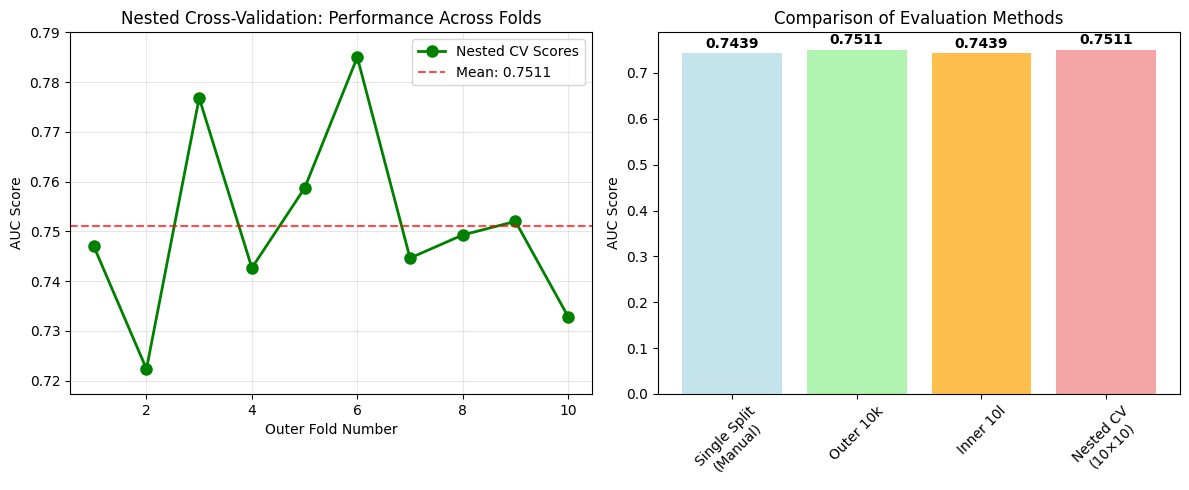

In [13]:
# Visualize nested CV results
plt.figure(figsize=(12, 5))

# Left plot: Individual fold scores
plt.subplot(1, 2, 1)
fold_numbers = list(range(1, 11))
plt.plot(fold_numbers, nested_scores, 'go-', linewidth=2, markersize=8, label='Nested CV Scores')
plt.axhline(y=np.mean(nested_scores), color='r', linestyle='--', alpha=0.7,
           label=f'Mean: {np.mean(nested_scores):.4f}')
plt.xlabel('Outer Fold Number')
plt.ylabel('AUC Score')
plt.title('Nested Cross-Validation: Performance Across Folds')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim([min(nested_scores)-0.005, max(nested_scores)+0.005])

# Right plot: Comparison of methods
plt.subplot(1, 2, 2)
methods = ['Single Split\n(Manual)', 'Outer 10k', 'Inner 10l', 'Nested CV\n(10×10)']
scores_comparison = [
    test_auc,  # From manual three-way split
    test_auc_cv,  # From outer cv loop
    test_auc_grid_10k,  # From 10-fold CV inner loop
    test_auc_nested  # From nested CV
]
colors = ['lightblue', 'lightgreen', 'orange', 'lightcoral']
bars = plt.bar(methods, scores_comparison, color=colors, alpha=0.7)
plt.ylabel('AUC Score')
plt.title('Comparison of Evaluation Methods')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, score in zip(bars, scores_comparison):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

#### Leave-One-Out Cross-Validation

**Leave-One-Out Cross-Validation (LOOCV)** uses each observation as a test set once, requiring n model fits for n observations. While this maximizes training data usage, it becomes computationally expensive for large datasets.

The main **downsides** are:
 - High computational cost (thousands of fits for typical datasets) and potential instability due to high variance in estimates.
 - Additionally, LOOCV is not feasible for hyperparameter tuning due to the computational burden, imagine running GridSearchCV with LOOCV!

**Practical recommendation:**
- Use 10-fold cross-validation for hyperparameter tuning for most applications.
- Reserve LOOCV only for final performance evaluation on very small datasets (< 100 observations) where computational cost is not a concern.

In order to practically implement LOOCV in this notebook, the following **workflow** is proposed:
1. **Dataset sampling:** Use stratified sampling to select 500 representative observations (to keep computation manageable)
2. **For each observation i in the sample:**
   - Use observation i as the test set (single observation)
   - Use all remaining 499 observations as the training set
   - Fit the model on the 499 training observations
   - Predict the class probability for observation i
   - Store the prediction and true label
3. **Calculate final performance:** Compute AUC using all 500 predictions and true labels
4. **Result:** One performance estimate based on 500 individual model fits

In [14]:
from sklearn.model_selection import LeaveOneOut
import time

# LOOCV Implementation with limited runs to demonstrate computational cost
print("This will demonstrate the computational challenge of LOOCV")
print("We'll limit to 500 observations to keep runtime reasonable\n")

# Use stratified sampling to maintain class balance (not first N samples!)
max_samples = 500  # Increased to get more positive cases for stable LOOCV
X_limited, _, y_limited, _ = train_test_split(
    X, y,
    train_size=max_samples,
    random_state=RANDOM_STATE,
    stratify=y  # Maintains same class proportion as full dataset
)

# Create LOOCV splitter
loo = LeaveOneOut()

# You can use the pipeline created earlier with K=50

# Store predictions and true labels for final AUC calculation
all_predictions = []
all_true_labels = []

# Track timing
start_time = time.time()

# Manual LOOCV loop (to show the process)
fold_count = 0
print("Running LOOCV ...")

for train_idx, test_idx in loo.split(X_limited):
    fold_count += 1

    # Get train/test data for this fold
    X_train_loo = X_limited.iloc[train_idx]
    X_test_loo = X_limited.iloc[test_idx]
    y_train_loo = y_limited.iloc[train_idx]
    y_test_loo = y_limited.iloc[test_idx]

    # Fit model and predict
    pipeline_cv.fit(X_train_loo, y_train_loo)
    pred_prob = pipeline_cv.predict_proba(X_test_loo)[0, 1]  # Probability of churn

    # Store results
    all_predictions.append(pred_prob)
    all_true_labels.append(y_test_loo.iloc[0])

end_time = time.time()

# Calculate final AUC using all predictions
loocv_auc = roc_auc_score(all_true_labels, all_predictions)

print(f"\n=== LOOCV Results ===")
print(f"Total computation time: {end_time - start_time:.1f} seconds")
print(f"Number of model fits: {max_samples}")
print(f"Final AUC: {loocv_auc:.4f}")

# Print computational comparison
print(f"\nComputational Comparison:")
print(f"\nFor full dataset ({len(X)} samples):")
full_loocv_time = (end_time - start_time) * len(X) / max_samples
print(f"Estimated LOOCV time: {full_loocv_time:.0f} seconds ({full_loocv_time/60:.1f} minutes)")
print("This demonstrates why LOOCV is impractical for large datasets!")


This will demonstrate the computational challenge of LOOCV
We'll limit to 500 observations to keep runtime reasonable

Running LOOCV ...

=== LOOCV Results ===
Total computation time: 0.7 seconds
Number of model fits: 500
Final AUC: 0.6287

Computational Comparison:

For full dataset (41739 samples):
Estimated LOOCV time: 62 seconds (1.0 minutes)
This demonstrates why LOOCV is impractical for large datasets!


In [15]:
# LOOCV results comparison with other methods
print("=== LOOCV vs Other Methods Comparison ===")
print(f"Dataset sizes:")
print(f"  LOOCV sample: {len(y_limited)} observations ({(y_limited==1).sum()} positive cases)")
print(f"  Other methods: {len(y)} observations ({(y==1).sum()} positive cases)")

print(f"\nAUC Performance Comparison:")
print(f"  Manual three-way split: {test_auc:.4f}")
print(f"  Outer 10-fold: {test_auc_cv:.4f}")
print(f"  Innter 10-fold: {test_auc_grid_10k:.4f}")
print(f"  Nested CV: {test_auc_nested:.4f}")
print(f"  LOOCV (500 samples): {loocv_auc:.4f}")

=== LOOCV vs Other Methods Comparison ===
Dataset sizes:
  LOOCV sample: 500 observations (19 positive cases)
  Other methods: 41739 observations (1573 positive cases)

AUC Performance Comparison:
  Manual three-way split: 0.7439
  Outer 10-fold: 0.7511
  Innter 10-fold: 0.7439
  Nested CV: 0.7511
  LOOCV (500 samples): 0.6287


Notice the worse performance of LOOCV:
- Much smaller training sets (~499 vs ~33,000 samples per fold)
- Higher variance due to extreme resampling
- Fewer positive cases per training fold (~18 vs ~1,200)

### Bootstrapping

A final evaluation setup is the **bootstrapping method** where observations can be sampled multiple times (with replacement) for training, while unused observations form the out-of-bag (OOB) test set. Unlike cross-validation's systematic partitioning, bootstrap creates overlapping training sets of the original size.

Note that sklearn doesn't provide a built-in bootstrap cross-validation function, so we implement it manually using `resample()`.

**Workflow:**
1. **For each of 50 iterations:**
   - Sample n observations with replacement from the dataset (bootstrap sample)
   - Use bootstrap sample as training set (contains duplicates)
   - Identify out-of-bag observations (never selected) as test set
   - Train KNN model (K=50) on bootstrap training set
   - Evaluate on out-of-bag test set and store AUC score
2. **Calculate final performance:** Average AUC across all 50 iterations
3. **Expected result:** ~36.8% out-of-bag rate per iteration

In [16]:
import numpy as np
from sklearn.utils import resample
import matplotlib.pyplot as plt
import time

# Bootstrap evaluation with 50 iterations
n_bootstrap_iterations = 50
bootstrap_scores = []

print(f"=== Bootstrap Evaluation ({n_bootstrap_iterations} iterations) ===")
print("Performing bootstrap sampling with replacement...")

# Track timing
start_time = time.time()

# Perform bootstrap iterations
for i in range(n_bootstrap_iterations):
    # Bootstrap sample with replacement (training set)
    X_bootstrap, y_bootstrap = resample(X, y,
                                       n_samples=len(X),
                                       random_state=RANDOM_STATE + i,
                                       stratify=y)  # Maintain class balance

    # Find out-of-bag samples (test set)
    # Convert to indices for comparison
    bootstrap_indices = set(X_bootstrap.index)
    oob_indices = [idx for idx in X.index if idx not in bootstrap_indices]

    # Skip if no out-of-bag samples (very rare)
    if len(oob_indices) == 0:
        continue

    # Get out-of-bag test set
    X_oob = X.loc[oob_indices]
    y_oob = y.loc[oob_indices]

    # Train model on bootstrap sample
    pipeline_cv.fit(X_bootstrap, y_bootstrap)

    # Evaluate on out-of-bag samples
    oob_probs = pipeline_cv.predict_proba(X_oob)[:, 1]
    oob_auc = roc_auc_score(y_oob, oob_probs)
    bootstrap_scores.append(oob_auc)

    # Show progress every 10 iterations
    if (i + 1) % 10 == 0:
        print(f"Completed {i + 1}/{n_bootstrap_iterations} iterations...")

end_time = time.time()

# Convert to numpy array for easier analysis
bootstrap_scores = np.array(bootstrap_scores)

print(f"\n=== Bootstrap Results ===")
print(f"Total computation time: {end_time - start_time:.1f} seconds")
print(f"Number of bootstrap iterations: {len(bootstrap_scores)}")
print(f"Mean AUC: {np.mean(bootstrap_scores):.4f}")
print(f"Standard deviation: {np.std(bootstrap_scores):.4f}")
print(f"95% Confidence interval: [{np.mean(bootstrap_scores) - 1.96*np.std(bootstrap_scores):.4f}, {np.mean(bootstrap_scores) + 1.96*np.std(bootstrap_scores):.4f}]")
print(f"Min AUC: {np.min(bootstrap_scores):.4f}")
print(f"Max AUC: {np.max(bootstrap_scores):.4f}")

# Verify out-of-bag rate
print(f"\nOut-of-bag analysis:")
print(f"Expected OOB rate: ~36.8% (theoretical)")
oob_rate = len(oob_indices) / len(X) * 100
print(f"Actual OOB rate (last iteration): {oob_rate:.1f}%")

=== Bootstrap Evaluation (50 iterations) ===
Performing bootstrap sampling with replacement...
Completed 10/50 iterations...
Completed 20/50 iterations...
Completed 30/50 iterations...
Completed 40/50 iterations...
Completed 50/50 iterations...

=== Bootstrap Results ===
Total computation time: 9.8 seconds
Number of bootstrap iterations: 50
Mean AUC: 0.7254
Standard deviation: 0.0114
95% Confidence interval: [0.7031, 0.7477]
Min AUC: 0.7018
Max AUC: 0.7489

Out-of-bag analysis:
Expected OOB rate: ~36.8% (theoretical)
Actual OOB rate (last iteration): 36.8%


### Comparison of all methods

Finally, let's make a (visual) comparison of all methods. The **conclusions** are:

- **Nested CV** provides gold standard: unbiased estimates with confidence intervals  
- **Outer CV** performs on par with nested CV since we used the best value of K.
- **Single splits** are fastest but least reliable: sensitive to random data division
- **Single splits with inner CV** are a bit slower but give a reliable hyperparameter estimates
- **LOOCV** shows computational limitations: impractical for large datasets
- **Bootstrap** offers alternative to CV: maintains original training set sizes
- **Performance consistency**: Most methods yield similar AUC (~0.74-0.75) showing model stability

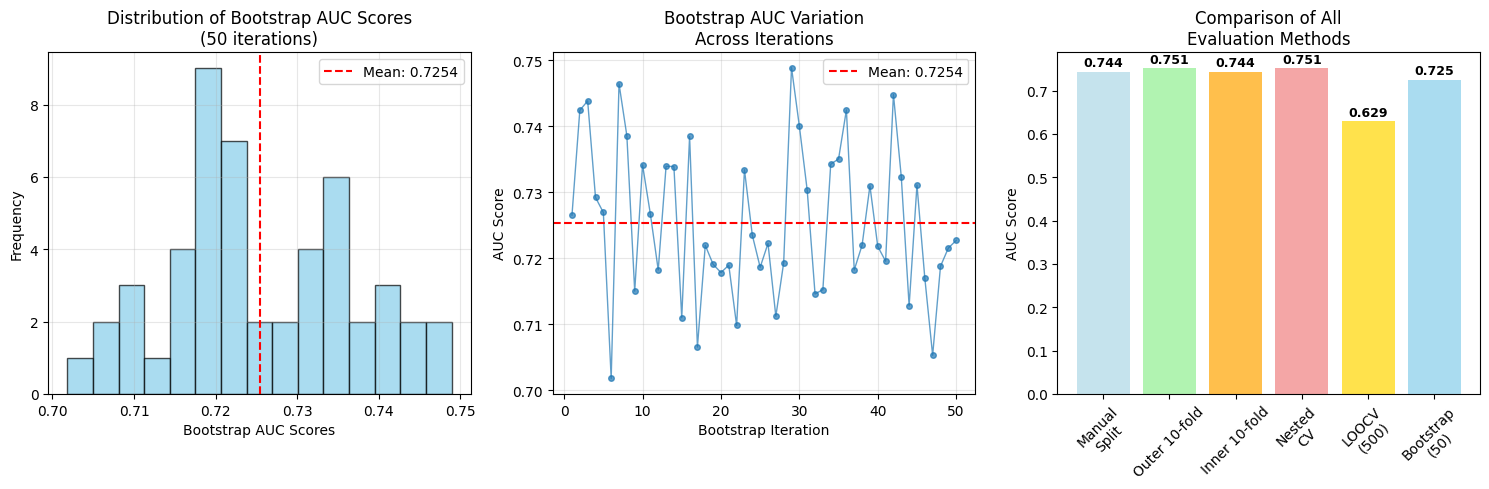


=== Complete Method Comparison ===
Manual three-way split:     0.7439
Outer 10-fold:  0.7511
Inner 10-fold:       0.7439
Nested CV (10x10):          0.7511
LOOCV (500 samples):        0.6287
Bootstrap (50 iterations):  0.7254 (±0.0114)


In [17]:
# Visualize bootstrap results and compare with other methods
plt.figure(figsize=(15, 5))

# Left plot: Bootstrap score distribution
plt.subplot(1, 3, 1)
plt.hist(bootstrap_scores, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(np.mean(bootstrap_scores), color='red', linestyle='--',
           label=f'Mean: {np.mean(bootstrap_scores):.4f}')
plt.xlabel('Bootstrap AUC Scores')
plt.ylabel('Frequency')
plt.title('Distribution of Bootstrap AUC Scores\n(50 iterations)')
plt.legend()
plt.grid(True, alpha=0.3)

# Middle plot: Bootstrap scores over iterations
plt.subplot(1, 3, 2)
plt.plot(range(1, len(bootstrap_scores) + 1), bootstrap_scores, 'o-',
         linewidth=1, markersize=4, alpha=0.7)
plt.axhline(y=np.mean(bootstrap_scores), color='r', linestyle='--',
           label=f'Mean: {np.mean(bootstrap_scores):.4f}')
plt.xlabel('Bootstrap Iteration')
plt.ylabel('AUC Score')
plt.title('Bootstrap AUC Variation\nAcross Iterations')
plt.legend()
plt.grid(True, alpha=0.3)

# Right plot: Method comparison
plt.subplot(1, 3, 3)
methods = ['Manual\nSplit', 'Outer 10-fold', 'Inner 10-fold', 'Nested\nCV', 'LOOCV\n(500)', 'Bootstrap\n(50)']
scores_comparison = [
    test_auc,  # Manual three-way split
    test_auc_cv,
    test_auc_grid_10k,  # 10-fold CV
    test_auc_nested,  # Nested CV
    loocv_auc,  # LOOCV
    np.mean(bootstrap_scores)  # Bootstrap
]
colors = ['lightblue', 'lightgreen', 'orange', 'lightcoral', 'gold', 'skyblue']
bars = plt.bar(methods, scores_comparison, color=colors, alpha=0.7)
plt.ylabel('AUC Score')
plt.title('Comparison of All\nEvaluation Methods')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, score in zip(bars, scores_comparison):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Summary comparison table
print("\n=== Complete Method Comparison ===")
print(f"Manual three-way split:     {test_auc:.4f}")
print(f"Outer 10-fold:  {test_auc_cv:.4f}")
print(f"Inner 10-fold:       {test_auc_grid_10k:.4f}")
print(f"Nested CV (10x10):          {test_auc_nested:.4f}")
print(f"LOOCV (500 samples):        {loocv_auc:.4f}")
print(f"Bootstrap (50 iterations):  {np.mean(bootstrap_scores):.4f} (±{np.std(bootstrap_scores):.4f})")

## Bias-Variance Trade-Off



## Bias-Variance Trade-off

A fundamental concept in machine learning is the **bias-variance trade-off**, which essentially comes down to finding the right model complexity. From our evaluation examples above, we've seen how different methods can yield varying performance estimates, this connects directly to how model complexity affects learning.

**The core challenge:**
- **High bias (underfitting)**: Model is too simple to capture underlying patterns
- **High variance (overfitting)**: Model is too complex and learns noise instead of signal
- **Optimal complexity**: Model captures true relationships without memorizing noise

**The complexity dilemma:**

A natural reaction might be to make models as complex as possible to improve performance. However, overly complex models learn the idiosyncrasies and noise in training data rather than generalizable patterns. This leads to poor performance on new, unseen data.

**Demonstration:**

We'll create a synthetic dataset where we control the true underlying relationship. By adding random noise, we simulate real-world factors that models shouldn't learn. This allows us to clearly observe how different model complexities handle the same data:

1. **Underfitting example**: Linear model on quadratic data
2. **Optimal fit example**: Quadratic model matching true relationship  
3. **Overfitting example**: High-degree polynomial learning noise

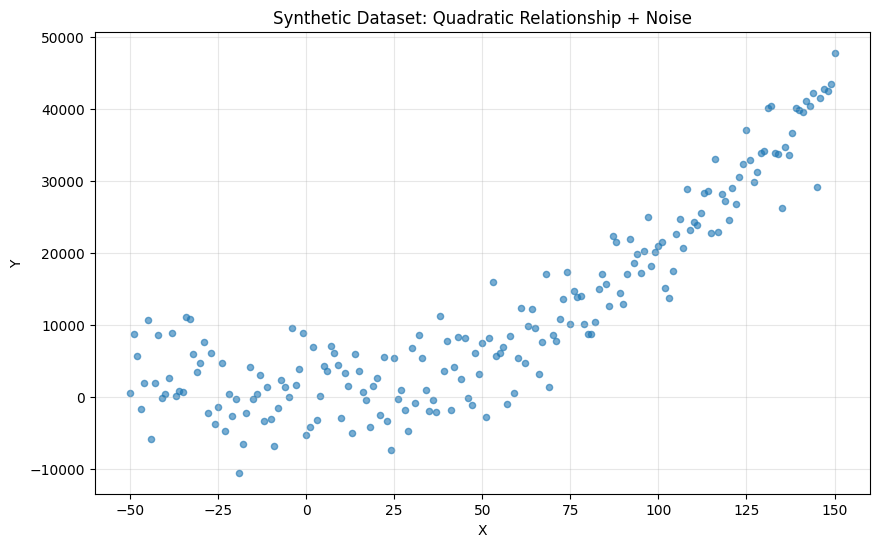

Data shape: 201 observations
True relationship: y = 3 + 2*x² + noise


In [18]:
# Create synthetic data with known quadratic relationship
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Generate data: true quadratic relationship + noise
np.random.seed(RANDOM_STATE)
x = np.arange(-50, 151)
y_true = 3 + 2 * x**2  # True underlying relationship
noise = np.random.normal(0, 4000, len(x))  # Random noise
y = y_true + noise

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=20)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Synthetic Dataset: Quadratic Relationship + Noise')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Data shape: {len(x)} observations")
print("True relationship: y = 3 + 2*x² + noise")

### 1. Underfitting: Linear Model (Too Simple)

First, let's try fitting a linear model to this clearly non-linear data. Although the $R^2$ of the model is good, this represents **underfitting**: the model is not complex enough to capture the true quadratic relationship.

Linear Model Results:
Coefficient: 197.31
Intercept: 1899.71
R-squared: 0.7223


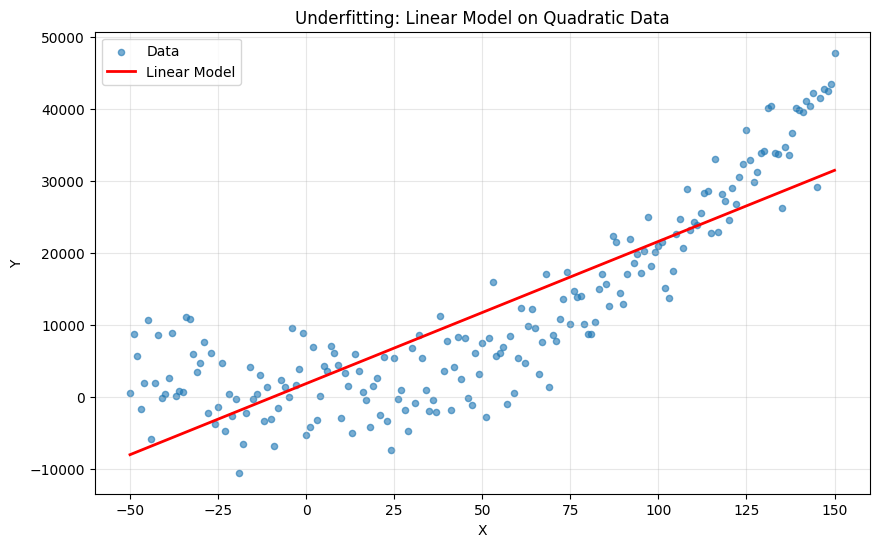

Observation: Linear model cannot capture the quadratic relationship (underfitting).


In [19]:
# Linear regression model (underfitting)
linear_model = LinearRegression()
linear_model.fit(x.reshape(-1, 1), y)

# Get predictions
y_linear_pred = linear_model.predict(x.reshape(-1, 1))

# Calculate R-squared
from sklearn.metrics import r2_score
r2_linear = r2_score(y, y_linear_pred)

print("Linear Model Results:")
print(f"Coefficient: {linear_model.coef_[0]:.2f}")
print(f"Intercept: {linear_model.intercept_:.2f}")
print(f"R-squared: {r2_linear:.4f}")

# Visualize the fit
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=20, label='Data')
plt.plot(x, y_linear_pred, 'r-', linewidth=2, label='Linear Model')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Underfitting: Linear Model on Quadratic Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Observation: Linear model cannot capture the quadratic relationship (underfitting).")

### 2. Overfitting: High-Degree Polynomial (Too Complex)

Now let's go to the other extreme: a high-degree polynomial model. This represents **overfitting**: the model is too complex and will learn noise in the data.

20th-Degree Polynomial Model Results:
R-squared: 0.7871
Number of coefficients: 20


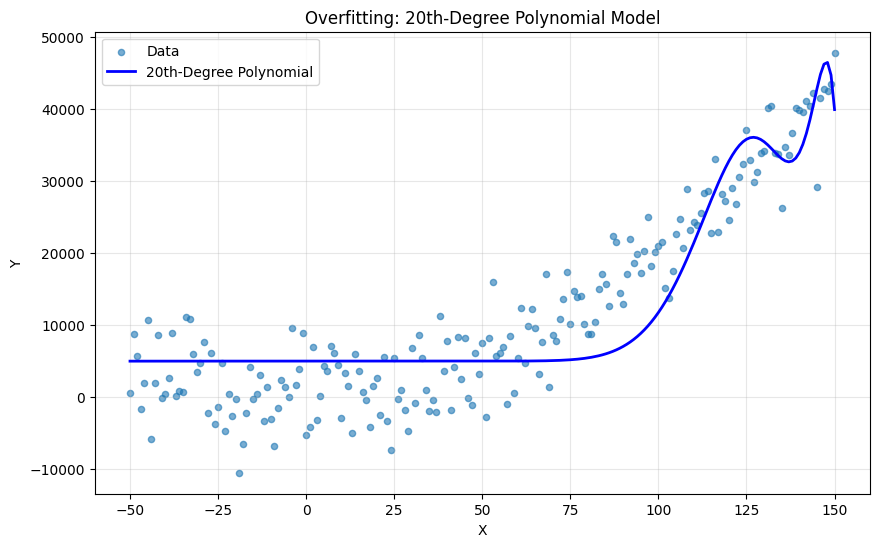

Observation: Polynomial shows 'wobbly' behavior due to overfitting to noise.


In [20]:
# High-degree polynomial regression (overfitting)
# Create polynomial features (degree 20)
poly_features_20 = PolynomialFeatures(degree=20, include_bias=False)
X_poly_20 = poly_features_20.fit_transform(x.reshape(-1, 1))

# Fit polynomial model
poly_model_20 = LinearRegression()
poly_model_20.fit(X_poly_20, y)

# Get predictions
y_poly_20_pred = poly_model_20.predict(X_poly_20)
r2_poly_20 = r2_score(y, y_poly_20_pred)

print("20th-Degree Polynomial Model Results:")
print(f"R-squared: {r2_poly_20:.4f}")
print(f"Number of coefficients: {len(poly_model_20.coef_)}")

# Visualize the fit
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=20, label='Data')
plt.plot(x, y_poly_20_pred, 'b-', linewidth=2, label='20th-Degree Polynomial')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Overfitting: 20th-Degree Polynomial Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Observation: Polynomial shows 'wobbly' behavior due to overfitting to noise.")

### 3. Optimal Complexity: Quadratic Model (Just Right)

Finally, let's fit the correct model: a quadratic polynomial that matches the true underlying relationship.

Quadratic Model Results:
R-squared: 0.9032
Coefficients: [7.0127756  1.90301009]
True relationship: y = 3 + 2*x²


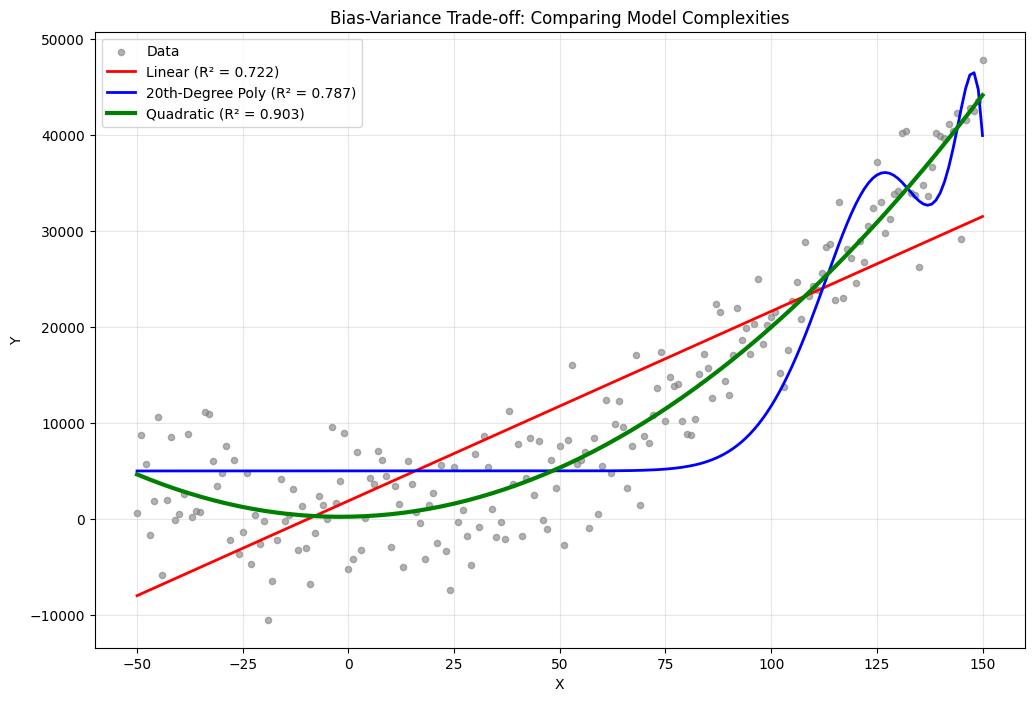


=== Model Comparison ===
Linear (Underfitting):    R² = 0.7223
Quadratic (Optimal):      R² = 0.9032
20th-Degree (Overfitting): R² = 0.7871


In [21]:
# Quadratic polynomial regression (optimal complexity)
# Create quadratic features (degree 2)
poly_features_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_2 = poly_features_2.fit_transform(x.reshape(-1, 1))

# Fit quadratic model
quad_model = LinearRegression()
quad_model.fit(X_poly_2, y)

# Get predictions
y_quad_pred = quad_model.predict(X_poly_2)
r2_quad = r2_score(y, y_quad_pred)

print("Quadratic Model Results:")
print(f"R-squared: {r2_quad:.4f}")
print(f"Coefficients: {quad_model.coef_}")
print(f"True relationship: y = 3 + 2*x²")

# Compare all three models
plt.figure(figsize=(12, 8))
plt.scatter(x, y, alpha=0.6, s=20, label='Data', color='gray')
plt.plot(x, y_linear_pred, 'r-', linewidth=2, label=f'Linear (R² = {r2_linear:.3f})')
plt.plot(x, y_poly_20_pred, 'b-', linewidth=2, label=f'20th-Degree Poly (R² = {r2_poly_20:.3f})')
plt.plot(x, y_quad_pred, 'g-', linewidth=3, label=f'Quadratic (R² = {r2_quad:.3f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Bias-Variance Trade-off: Comparing Model Complexities')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Model comparison summary
print("\n=== Model Comparison ===")
print(f"Linear (Underfitting):    R² = {r2_linear:.4f}")
print(f"Quadratic (Optimal):      R² = {r2_quad:.4f}")
print(f"20th-Degree (Overfitting): R² = {r2_poly_20:.4f}")

## Performance measures



### Regression

The bias-variance demonstration above was straightforward because we knew the true underlying relationship. However, in real-world scenarios, this relationship is unknown. This is where **performance metrics** become crucial for model selection and evaluation.

**Real-world scenario**: Consider our synthetic data where `X` represents *time* and `y` represents *profit* during that period. Since profit follows a stable pattern, we want to predict profit for future periods (beyond X = 150).

**Key assumption**: The current underlying relationship will remain the same for future predictions. This assumption is critical but not always valid in practice, violating it can cause serious issues in deployed models.

**Strategy**: We'll test different model specifications and select the one with the best performance on hold-out test data. This approach simulates real-world model selection where the true relationship is unknown.

**Data splitting for model comparison**:
- **Training set**: First 121 observations (60% of data) --> for learning model parameters  
- **Validation set**: Next 40 observations (20% of data) --> for model selection and hyperparameter tuning
- **Test set**: Final 40 observations (20% of data) --> for final evaluation

This setup mirrors practical scenarios where we need to choose between competing models without knowing which specification is "correct."

In [22]:
# Create train/validation/test splits using the synthetic data from bias-variance example
# Data: x (time), y (profit with noise)

# Convert to DataFrame for easier manipulation
# Add a quadratic term, 4 and 5-power polynomial
regression_data = pd.DataFrame({
    'x': x,
    'x_squared': x**2,  # Precompute for quadratic model
    'x_4': x**4,
    'x_5': x**5,
    'y': y
})

# Create train/validation/test splits
# Training: first 121 observations (60%)
# Validation: next 40 observations (20%)
# Test: final 40 observations (20%)
train_end = 121
val_end = 161

train_data = regression_data.iloc[:train_end].copy()
val_data = regression_data.iloc[train_end:val_end].copy()
test_data = regression_data.iloc[val_end:].copy()

print(f"Training set: {len(train_data)} observations (x: {train_data['x'].min():.0f} to {train_data['x'].max():.0f})")
print(f"Validation set: {len(val_data)} observations (x: {val_data['x'].min():.0f} to {val_data['x'].max():.0f})")
print(f"Test set: {len(test_data)} observations (x: {test_data['x'].min():.0f} to {test_data['x'].max():.0f})")

# Prepare feature matrices and target vectors
X_train_reg = train_data[['x', 'x_squared', 'x_4', 'x_5']]
y_train_reg = train_data['y']

X_val_reg = val_data[['x', 'x_squared', 'x_4', 'x_5']]
y_val_reg = val_data['y']

X_test_reg = test_data[['x', 'x_squared', 'x_4', 'x_5']]
y_test_reg = test_data['y']

Training set: 121 observations (x: -50 to 70)
Validation set: 40 observations (x: 71 to 110)
Test set: 40 observations (x: 111 to 150)


#### Model Training and Comparison

We'll train three competing models on our training data and evaluate their performance on the validation set:

1. **Linear Model**: Uses only `x` (underfitting expected)
2. **Quadratic Model**: Uses `x` and `x²` (optimal complexity expected)
3. **High-order Polynomial**: Uses `x⁴`, `x⁵` (overfitting expected)


In [23]:
# Train three competing models on training data
# 1. Linear model (underfitting)
linear_reg = LinearRegression()
linear_reg.fit(X_train_reg[['x']], y_train_reg)

# 2. Quadratic model (optimal complexity)
quadratic_reg = LinearRegression()
quadratic_reg.fit(X_train_reg[['x', 'x_squared']], y_train_reg)

# 3. High-order polynomial (overfitting)
# Use manually crafted x^4 and x^5 features
poly_reg = LinearRegression()
poly_reg.fit(X_train_reg[['x_4', 'x_5']], y_train_reg)

# Generate predictions on validation set
val_pred_linear = linear_reg.predict(X_val_reg[['x']])
val_pred_quadratic = quadratic_reg.predict(X_val_reg[['x', 'x_squared']])
val_pred_poly = poly_reg.predict(X_val_reg[['x_4', 'x_5']])

print("Models trained successfully on training data")
print(f"Validation predictions generated for {len(val_data)} observations")

Models trained successfully on training data
Validation predictions generated for 40 observations


#### Regression Performance Metrics

Several metrics exist for evaluating regression models. We'll implement the four most popular ones using sklearn's built-in functions where available:

**Key metrics for regression**:
- **R² (R-squared)**: Proportion of variance explained (0 to 1, higher is better)
- **RMSE (Root Mean Square Error)**: Average prediction error magnitude (lower is better)  
- **MAE (Mean Absolute Error)**: Average absolute prediction error (lower is better)
- **MAPE (Mean Absolute Percentage Error)**: Average percentage error (0 to 1, lower is better)

**Important notes**:
- **R²** is primarily used for goodness-of-fit assessment on training data
- **RMSE, MAE, MAPE** are preferred for predictive performance evaluation
- Only **R²** should be maximized; all others should be minimized
- **MAPE** and **R²** are scale-independent, making them easier to interpret across different datasets
- **Negative R²**: When evaluating on test/validation sets, R² can be negative if the model performs worse than simply predicting the mean. This indicates severe overfitting or model inadequacy.



In [24]:
# Calculate regression performance metrics using sklearn
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Define MAPE function (not available in sklearn)
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error (MAPE)"""
    return np.mean(np.abs((y_true - y_pred) / y_true))

# Function to calculate all metrics at once
def regression_metrics(y_true, y_pred, model_name):
    """Calculate comprehensive regression metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R²': r2
    }

# Calculate metrics for all models on validation set
results = []
results.append(regression_metrics(y_val_reg, val_pred_linear, 'Linear'))
results.append(regression_metrics(y_val_reg, val_pred_quadratic, 'Quadratic'))
results.append(regression_metrics(y_val_reg, val_pred_poly, '5th-Degree Polynomial'))

# Convert to DataFrame for nice display
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("=== Validation Set Performance Comparison ===")
print(results_df.to_string(index=False))

# Identify best model for each metric
print(f"\nBest R² (highest): {results_df.loc[results_df['R²'].idxmax(), 'Model']} ({results_df['R²'].max():.4f})")
print(f"Best RMSE (lowest): {results_df.loc[results_df['RMSE'].idxmin(), 'Model']} ({results_df['RMSE'].min():.4f})")
print(f"Best MAE (lowest): {results_df.loc[results_df['MAE'].idxmin(), 'Model']} ({results_df['MAE'].min():.4f})")
print(f"Best MAPE (lowest): {results_df.loc[results_df['MAPE'].idxmin(), 'Model']} ({results_df['MAPE'].min():.4f})")

=== Validation Set Performance Comparison ===
                Model       RMSE        MAE   MAPE      R²
               Linear 12320.0463 11360.3582 0.6345 -4.8639
            Quadratic  4045.5159  3354.9308 0.1927  0.3677
5th-Degree Polynomial 10374.3026  8295.9705 0.4918 -3.1580

Best R² (highest): Quadratic (0.3677)
Best RMSE (lowest): Quadratic (4045.5159)
Best MAE (lowest): Quadratic (3354.9308)
Best MAPE (lowest): Quadratic (0.1927)



Let's visualize how well each model fits the validation data. The plot shows predictions vs. true values - perfect predictions would form a straight diagonal line.

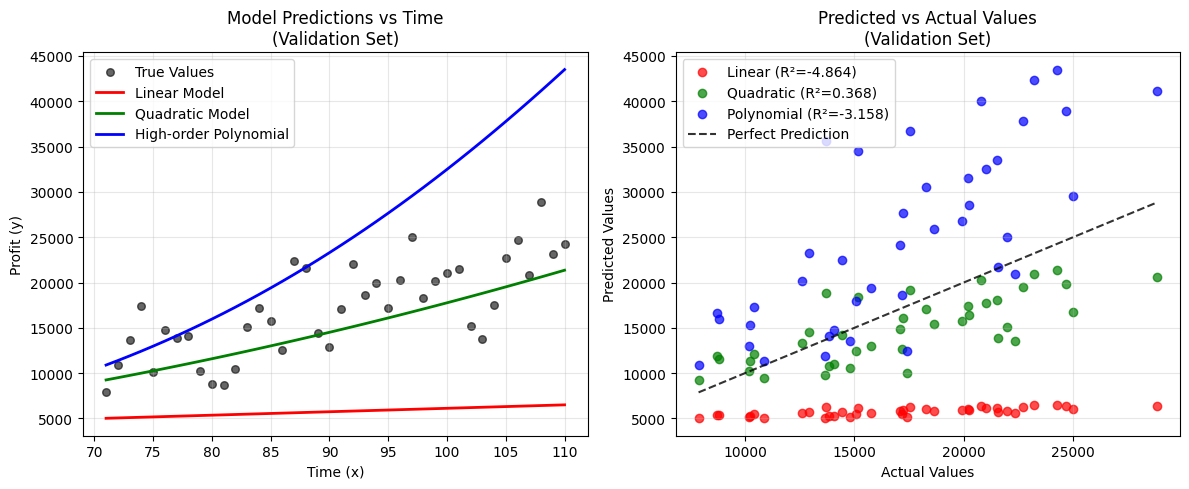

In [25]:
# Visualize model predictions vs actual values on validation set
plt.figure(figsize=(12, 5))

# Plot predictions vs. time (x-axis)
plt.subplot(1, 2, 1)
plt.scatter(X_val_reg['x'], y_val_reg, alpha=0.6, s=30, color='black', label='True Values')
plt.plot(X_val_reg['x'], val_pred_linear, 'r-', linewidth=2, label='Linear Model')
plt.plot(X_val_reg['x'], val_pred_quadratic, 'g-', linewidth=2, label='Quadratic Model')
plt.plot(X_val_reg['x'], val_pred_poly, 'b-', linewidth=2, label='High-order Polynomial')
plt.xlabel('Time (x)')
plt.ylabel('Profit (y)')
plt.title('Model Predictions vs Time\n(Validation Set)')
plt.legend()
plt.grid(True, alpha=0.3)

# Predicted vs Actual scatter plots
plt.subplot(1, 2, 2)
plt.scatter(y_val_reg, val_pred_linear, alpha=0.7, color='red', label=f'Linear (R²={results_df.iloc[0]["R²"]:.3f})')
plt.scatter(y_val_reg, val_pred_quadratic, alpha=0.7, color='green', label=f'Quadratic (R²={results_df.iloc[1]["R²"]:.3f})')
plt.scatter(y_val_reg, val_pred_poly, alpha=0.7, color='blue', label=f'Polynomial (R²={results_df.iloc[2]["R²"]:.3f})')

# Perfect prediction line
min_val, max_val = y_val_reg.min(), y_val_reg.max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values\n(Validation Set)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Key Observations

**Performance Analysis:**
- **Quadratic model (green)** shows the best performance across all metrics
- **Linear model (red)** systematically underestimates high values, indicating **underfitting**
- **High-order polynomial model (blue)** shows erratic behavior, indicating **overfitting**

In sum, the quadratic model strikes the best balance between model complexity and generalization ability


#### Final Model Evaluation

Based on validation performance, the quadratic model is clearly superior. Following best practices, we now:

1. **Retrain** the best model on **combined training + validation data** (remember more data typically improves performance)
2. **Evaluate** final performance on the **untouched test set** for unbiased estimation
3. **Compare** model performance after joining the train and validation set.

You will notice that model performance improved across all metrics when training on more data.

In [26]:
# Step 1: Combine training and validation data for final model training
train_val_data = pd.concat([train_data, val_data], ignore_index=True)
X_train_val = train_val_data[['x', 'x_squared']]
y_train_val = train_val_data['y']

print(f"Combined training set: {len(train_val_data)} observations")
print(f"Test set: {len(test_data)} observations")

# Step 2: Retrain quadratic model on expanded dataset
final_quadratic_model = LinearRegression()
final_quadratic_model.fit(X_train_val, y_train_val)

# Step 3: Generate final predictions on test set (first time seeing this data!)
test_predictions = final_quadratic_model.predict(X_test_reg[['x', 'x_squared']])

# Step 4: Calculate final test performance
final_metrics = regression_metrics(y_test_reg, test_predictions, 'Final Quadratic Model')

# Step 5: Compare performance metrics - validation vs test set
print("\n=== Performance Change Analysis ===")

# Get validation metrics for the quadratic model
validation_metrics = results_df[results_df['Model'] == 'Quadratic'].iloc[0]

# Compare all metrics
metrics_to_compare = ['R²', 'RMSE', 'MAE', 'MAPE']
print("Metric          Validation    Test        Change")
print("-" * 50)

for metric in metrics_to_compare:
    val_score = validation_metrics[metric]
    test_score = final_metrics[metric]
    change = test_score - val_score

    print(f"{metric:<12}    {val_score:>8.4f}    {test_score:>8.4f}    {change:>+8.4f}")

Combined training set: 161 observations
Test set: 40 observations

=== Performance Change Analysis ===
Metric          Validation    Test        Change
--------------------------------------------------
R²                0.3677      0.6835     +0.3158
RMSE            4045.5159    3665.8844    -379.6315
MAE             3354.9308    2492.5076    -862.4232
MAPE              0.1927      0.0804     -0.1123


### Classification

A somewhat similar approach can be followed when dealing with classification tasks. Also with classification tasks, several popular metrics exist. Remember the example of the **churn case**? We will also be using that case for the discussion on classification measures.

With classification tasks, you can not simply measure the error, as all correct observations would have an error of 0 (0-0 or 1-1 in binary classification) and all incorrect observations would have an error of 1 (1-0 or 0-1). To handle this, most popular performance measures are based on a concept called the **confusion matrix**. The confusion matrix makes a cross tabulation of actual values and predicted values.

**Demonstration**:

We'll use the basetable of the **churn** example to showcase the various classification metrics. However, we will create new 50/50 train/test split for our classification analysis to make sure that we have enough test observations. We will also build a **Random Forest** model to demonstrate various classification metrics.

**Note:** Random Forest is an advanced ensemble model that builds hundreds of decision trees and combines their predictions. It is considered one of the best off-the-shelf classifiers even without hyperparameter tuning. At this stage, you don’t need to understand the internal mechanics, the focus is on how to set up the classification analysis and evaluate the results.


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Create 50/50 split using the original churn dataset
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    basetable.drop('churn', axis=1), basetable['churn'],
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=basetable['churn']  # Maintain class balance in both sets
)

# Build Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train_clf, y_train_clf)

print(f"\nRandom Forest model trained with {rf_model.n_estimators} trees")


Random Forest model trained with 100 trees


#### Confusion Matrix and Basic Metrics

Let's start by examining the confusion matrix using the default **threshold of 0.5**. Ideally, we would want all observations to be positioned on the diagonal. However, this is often infeasible in most real life situations, as no model is perfect.

Note that specificity is not available in sklearn so we have to compute this manually.

=== Confusion Matrix and Performance Metrics (Default Threshold = 0.5) ===
=== Performance Metrics using sklearn ===
Accuracy:    0.9610
Precision:   0.3725
Recall:      0.0483
F1-Score:    0.0855
Specificity: 0.9968


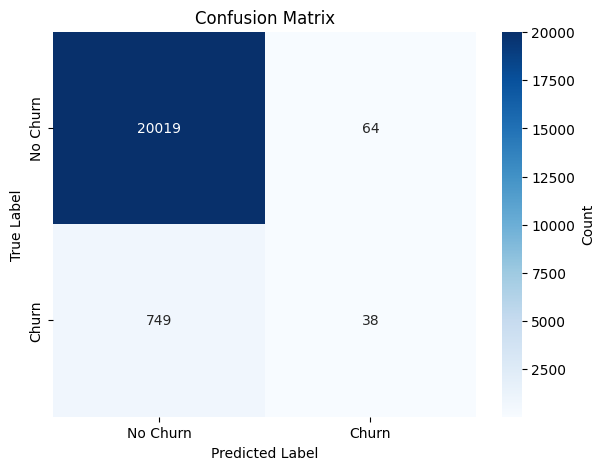

In [28]:
# Make predictions using default threshold (0.5)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

y_pred_default = rf_model.predict(X_test_clf)
y_proba = rf_model.predict_proba(X_test_clf)[:, 1]  # Probability of churn (class 1)

print("=== Confusion Matrix and Performance Metrics (Default Threshold = 0.5) ===")

# Create visualizations using matplotlib/seaborn (no compatibility issues!)
plt.figure(figsize=(15, 5))

# Left plot: Confusion matrix using seaborn
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test_clf, y_pred_default)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Use sklearn's built-in metrics
print("=== Performance Metrics using sklearn ===")
print(f"Accuracy:    {accuracy_score(y_test_clf, y_pred_default):.4f}")
print(f"Precision:   {precision_score(y_test_clf, y_pred_default):.4f}")
print(f"Recall:      {recall_score(y_test_clf, y_pred_default):.4f}")
print(f"F1-Score:    {f1_score(y_test_clf, y_pred_default):.4f}")

# Calculate specificity manually (sklearn doesn't have this built-in)
tn, fp, fn, tp = confusion_matrix(y_test_clf, y_pred_default).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"Specificity: {specificity:.4f}")

**Key Insights:**
- **High** **specificity** indicates good true negative rate, but the **low** **recall** shows a low true positive rate. Hence, the model is better in detecting non-churners than churners  
- Class imbalance leads to **high** overall **accuracy** but poor minority class performance  
- Threshold **optimization** may improve churn detection

#### Threshold Impact Analysis

The performance measures we calculated above are dependent on the used threshold. Let's see what happens when we alter the threshold to, for instance, 0.05 instead of the default 0.5. This demonstrates how threshold selection dramatically affects model performance and especially in this case with high class imbalance.

In [29]:
# First, let's examine the class imbalance in our dataset
print("=== Class Imbalance Analysis ===")
print("Training set distribution:")
print(f"  No Churn (0): {(y_train_clf == 0).sum():,} ({(y_train_clf == 0).mean()*100:.1f}%)")
print(f"  Churn (1):    {(y_train_clf == 1).sum():,} ({(y_train_clf == 1).mean()*100:.1f}%)")
print(f"  Total:        {len(y_train_clf):,}")

print("\nTest set distribution:")
print(f"  No Churn (0): {(y_test_clf == 0).sum():,} ({(y_test_clf == 0).mean()*100:.1f}%)")
print(f"  Churn (1):    {(y_test_clf == 1).sum():,} ({(y_test_clf == 1).mean()*100:.1f}%)")
print(f"  Total:        {len(y_test_clf):,}")

# Apply different threshold (0.05) and compare results
threshold_low = 0.05
y_pred_low_threshold = (y_proba > threshold_low).astype(int)

# Calculate metrics using sklearn (much cleaner!)
def calculate_metrics_sklearn(y_true, y_pred):
    """Calculate classification metrics using sklearn functions"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)  # recall = sensitivity

    # Specificity still needs manual calculation (sklearn doesn't have it)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return accuracy, sensitivity, specificity, precision

# Compare metrics using sklearn functions
metrics_default = calculate_metrics_sklearn(y_test_clf, y_pred_default)
metrics_low = calculate_metrics_sklearn(y_test_clf, y_pred_low_threshold)

print(f"\n=== Metrics Comparison ===")
print(f"Metric              Threshold=0.5    Threshold={threshold_low}")
print(f"Accuracy               {metrics_default[0]:8.4f}        {metrics_low[0]:8.4f}")
print(f"Sensitivity/Recall     {metrics_default[1]:8.4f}        {metrics_low[1]:8.4f}")
print(f"Specificity            {metrics_default[2]:8.4f}        {metrics_low[2]:8.4f}")
print(f"Precision              {metrics_default[3]:8.4f}        {metrics_low[3]:8.4f}")

=== Class Imbalance Analysis ===
Training set distribution:
  No Churn (0): 20,083 (96.2%)
  Churn (1):    786 (3.8%)
  Total:        20,869

Test set distribution:
  No Churn (0): 20,083 (96.2%)
  Churn (1):    787 (3.8%)
  Total:        20,870

=== Metrics Comparison ===
Metric              Threshold=0.5    Threshold=0.05
Accuracy                 0.9610          0.8056
Sensitivity/Recall       0.0483          0.5756
Specificity              0.9968          0.8146
Precision                0.3725          0.1085


**Key insights**:
- Lower threshold dramatically improves churn detection --> sensitivity increased from 0.05 to 0.58  
- But accuracy, specificity precision decreased due to more false positives  
- This demonstrates the **threshold-dependent nature** of classification metrics and especially in high imbalance settings.

#### Optimal Threshold Analysis

We've seen how different thresholds affect performance and especially in high class imbalance situation, but how do we find the **optimal threshold**? Luckily, there is a function called `TunedThresholdClassifierCV` which automatically finds the best threshold by optimizing a specified metric through cross-validation.

This approach is particularly useful when you want to focus on a business-relevant objective (such as maximizing F1-score, precision, or recall) instead of relying on the default threshold of 0.5. In our churn example, the goal might be to detect as many churners as possible. In that case, optimizing for recall or precision would be more appropriate. Since the F1, strikes a balance between precision and recall we will choose this one here.

**Note**: you will notice that here we use the function `StratifiedKFold` instead `KFold` to create our folds. When working with imbalanced data it is good practice to always use the stratified alternative. For larger datasets (>10000 observations) `KFold` will most often give approximately stratified folds, however, when the dataset sizes are smaller some variation might occur. Hence, it is better to be safe than sorry and always use `StratifiedKFold`.

In [30]:
# Optimal Threshold Analysis using TunedThresholdClassifierCV
from sklearn.model_selection import TunedThresholdClassifierCV, StratifiedKFold

print("=== F1-Optimized Threshold Analysis ===")

# Create F1-optimized threshold classifier
base_rf = RandomForestClassifier(n_estimators=10, random_state=RANDOM_STATE)
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tuned_clf = TunedThresholdClassifierCV(
    estimator=base_rf, scoring='f1', cv=cv_splitter, n_jobs=-1
)
tuned_clf.fit(X_train_clf, y_train_clf)

print(f"F1-optimized threshold: {tuned_clf.best_threshold_:.4f}")
print(f"Cross-validation F1 score: {tuned_clf.best_score_:.4f}")

# Compare default vs F1-optimized performance using existing function
y_pred_f1_opt = tuned_clf.predict(X_test_clf)

metrics_default = calculate_metrics_sklearn(y_test_clf, y_pred_default)
metrics_f1_opt = calculate_metrics_sklearn(y_test_clf, y_pred_f1_opt)

print(f"\n=== Test Set Performance Comparison ===")
print(f"Metric              Default(0.5)    F1-Optimized")
print("-" * 45)
print(f"Accuracy               {metrics_default[0]:8.4f}        {metrics_f1_opt[0]:8.4f}")
print(f"Sensitivity/Recall     {metrics_default[1]:8.4f}        {metrics_f1_opt[1]:8.4f}")
print(f"Specificity            {metrics_default[2]:8.4f}        {metrics_f1_opt[2]:8.4f}")
print(f"Precision              {metrics_default[3]:8.4f}        {metrics_f1_opt[3]:8.4f}")

# Calculate F1 scores for comparison
f1_default = f1_score(y_test_clf, y_pred_default)
f1_opt = f1_score(y_test_clf, y_pred_f1_opt)
print(f"F1-Score               {f1_default:8.4f}        {f1_opt:8.4f}")


=== F1-Optimized Threshold Analysis ===
F1-optimized threshold: 0.2121
Cross-validation F1 score: 0.2071

=== Test Set Performance Comparison ===
Metric              Default(0.5)    F1-Optimized
---------------------------------------------
Accuracy                 0.9610          0.9379
Sensitivity/Recall       0.0483          0.2313
Specificity              0.9968          0.9656
Precision                0.3725          0.2085
F1-Score                 0.0855          0.2193


**Key Insights**:
- F1-optimized threshold **balances** precision and recall, however precision decreased whereas recall increased
- Threshold optimization improves **minority class detection**, but still precision and recall remain low indicating that the classifier is not that good in detecting churners.
- Threshold optimization is crucial for imbalanced classification problems like churn prediction. If you want to even further solve the class imbalance problem, sampling approach like under- and oversampling can be done or cost-sensitive learning.

#### ROC Curve and AUC Analysis

Since performance metrics depend heavily on the chosen threshol and you often don't know the operating conditions, **threshold-independent measures** are often employed. The most popular threshold-independent measure is the **AUROC** or **AUC**, the Area Under the Receiver Operating Characteristic curve.

The **ROC curve** plots sensitivity (True Positive Rate) against 1-specificity (False Positive Rate) across different thresholds. The AUC calculates the area under this curve, providing a single metric that evaluates model performance across all possible thresholds. A **random classifier** has an AUC of 0.50.

There are two ways to compute the AUC with sklearn
1. Make the ROC curve with `roc_curve()` and compute the auc on this ROC curve
2. Directly compute the AUC with `roc_auc_score``

Always make sure to also plot the ROC curve to see the trade-off between the TPR and FPR.

=== ROC Curve and AUC Analysis ===
AUC using sklearn.metrics.auc(): 0.7639
AUC using roc_auc_score(): 0.7639


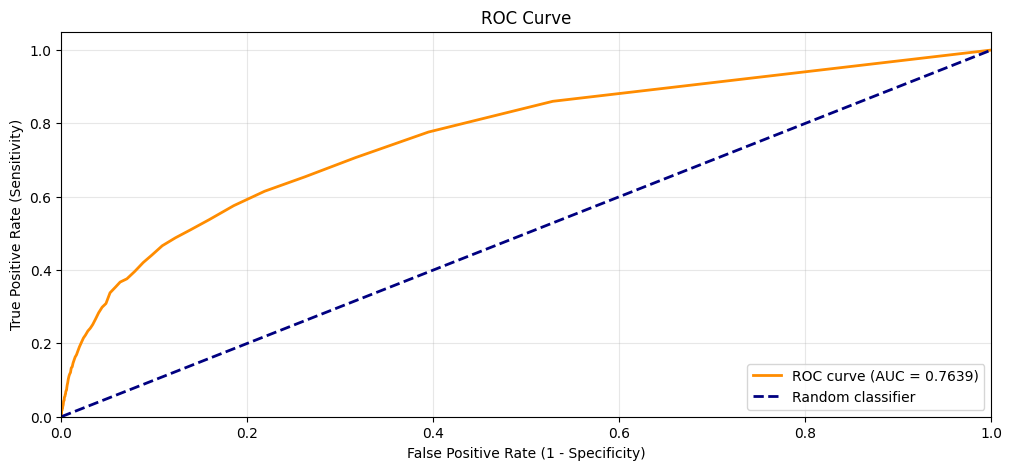

In [31]:
# Create ROC curve and calculate AUC using sklearn
from sklearn.metrics import roc_curve, auc, roc_auc_score

print("=== ROC Curve and AUC Analysis ===")

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_proba)
roc_auc = auc(fpr, tpr)

# Alternative: Direct AUC calculation
roc_auc_direct = roc_auc_score(y_test_clf, y_proba)

print(f"AUC using sklearn.metrics.auc(): {roc_auc:.4f}")
print(f"AUC using roc_auc_score(): {roc_auc_direct:.4f}")

# Create ROC curve visualization
plt.figure(figsize=(12, 5))

# Left plot: Manual ROC curve
plt.subplot()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


For educational purposes, a **manual** computation of the ROC curve is also performed.

The **procedure** for manually calculating a ROC curve involves the following steps:

1. **Threshold Generation**
    - Create a range of threshold values from minimum to maximum predicted probabilities
    - Use a specified step size (e.g., 0.01 or 0.05) to determine granularity
    - More thresholds = smoother curve but higher computational cost

2. **For Each Threshold Value:**

    - **Binary Classification**
        - Convert probabilities to binary predictions: `y_pred = (y_scores >= threshold)`
   
    - **Confusion Matrix Calculation**
        - Compute TP, FP, TN, FN

    - **Performance Metrics**
        - **TPR (True Positive Rate/Sensitivity)**: `TP / (TP + FN)` --> How well we detect churners
        - **FPR (False Positive Rate)**: `FP / (FP + TN)` --> How often we incorrectly flag non-churners

    - **ROC Curve Construction**
        - Plot FPR (x-axis) vs TPR (y-axis) for all threshold values
        - Each (FPR, TPR) pair represents one point on the ROC curve
        - Connect points to form the complete curve

In [32]:
# Manual ROC calculation for educational purposes
def manual_roc_calculation(y_true, y_scores, step_size=0.01):
    """
    Manual ROC curve calculation to demonstrate the underlying process
    """
    thresholds = np.arange(np.min(y_scores), np.max(y_scores) + step_size, step_size)
    tpr_values = []
    fpr_values = []

    for threshold in thresholds:
        y_pred_thresh = (y_scores >= threshold).astype(int)

        # Calculate confusion matrix elements
        TP = np.sum((y_true == 1) & (y_pred_thresh == 1))
        TN = np.sum((y_true == 0) & (y_pred_thresh == 0))
        FP = np.sum((y_true == 0) & (y_pred_thresh == 1))
        FN = np.sum((y_true == 1) & (y_pred_thresh == 0))

        # Calculate TPR and FPR
        tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0

        tpr_values.append(tpr)
        fpr_values.append(fpr)

    return np.array(fpr_values), np.array(tpr_values)

# Calculate manual ROC (with larger step size for demonstration)
fpr_manual, tpr_manual = manual_roc_calculation(y_test_clf, y_proba, step_size=0.05)

print(f"\n=== Manual ROC Calculation ===")
print(f"Number of threshold points (sklearn): {len(fpr)}")
print(f"Number of threshold points (manual): {len(fpr_manual)}")
print(f"Sklearn uses optimal thresholds for more precise calculation")


=== Manual ROC Calculation ===
Number of threshold points (sklearn): 84
Number of threshold points (manual): 19
Sklearn uses optimal thresholds for more precise calculation


#### Precision-Recall Curves and Average Precision

Besides the AUC and the ROC curve, **Precision-Recall (PR) curves** are often more informative than ROC curves for **imbalanced datasets**,. While ROC curves can be overly optimistic when the negative class is dominan (each class is weighted equally), PR curves focus on the minority class (churners) and provide a more realistic assessment of model performance.

The **Average Precision (AP)** summarizes the PR curve as the weighted mean of precisions achieved at each threshold, with the increase in recall from the previous threshold used as the weight. The values of the AP range from 0 to 1 and a **random classifier** has an average precision equal to the positive rate in the test set.

=== Precision-Recall Curve and Average Precision Analysis ===
Average Precision (AP) using average_precision_score(): 0.1641
Average Precision (AP) using manual auc() calculation: 0.1679
No-skill baseline (random classifier AP): 0.0377
Model improvement over random: 4.35x


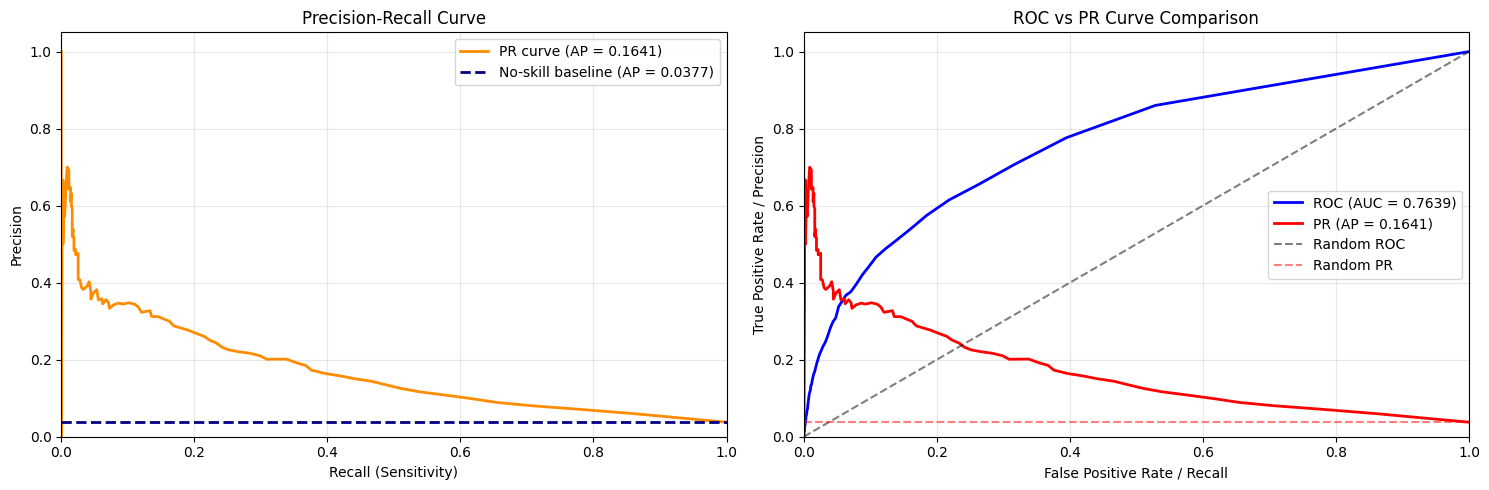

In [33]:
# Calculate Precision-Recall curves and Average Precision
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, auc

print("=== Precision-Recall Curve and Average Precision Analysis ===")

# Calculate PR curve
precision, recall, pr_thresholds = precision_recall_curve(y_test_clf, y_proba)
average_precision = average_precision_score(y_test_clf, y_proba)

# Alternative AP calculation using auc() function
ap_manual = auc(recall, precision)

print(f"Average Precision (AP) using average_precision_score(): {average_precision:.4f}")
print(f"Average Precision (AP) using manual auc() calculation: {ap_manual:.4f}")

# No-skill baseline (random classifier performance)
no_skill = np.sum(y_test_clf) / len(y_test_clf)  # Same as baseline churn rate
print(f"No-skill baseline (random classifier AP): {no_skill:.4f}")
print(f"Model improvement over random: {average_precision/no_skill:.2f}x")

# Create comprehensive PR curve visualization
plt.figure(figsize=(15, 5))

# Left plot: Manual PR curve with detailed annotations
plt.subplot(1, 2, 1)
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'PR curve (AP = {average_precision:.4f})')
plt.axhline(y=no_skill, color='navy', linestyle='--', lw=2,
            label=f'No-skill baseline (AP = {no_skill:.4f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# Right plot: ROC vs PR comparison for imbalanced data insights
plt.subplot(1, 2, 2)
# Plot both curves on same scale for comparison
fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot(recall, precision, color='red', lw=2, label=f'PR (AP = {average_precision:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random ROC')
plt.axhline(y=no_skill, color='red', linestyle='--', alpha=0.5, label='Random PR')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate / Recall')
plt.ylabel('True Positive Rate / Precision')
plt.title('ROC vs PR Curve Comparison')
plt.legend(loc="center right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key Insights:**
- **PR curve** provides a more realistic view than ROC for imbalanced datasets.
- **ROC AUC** may appear high (0.76) but can be **misleading under class imbalance**. This is also evident since the AP score (0.16) is not that high.
- **PR curve** emphasizes performance on the **minority class (churners)**.  
- The **shape of the PR curve** reveals the **precision–recall trade-offs** across thresholds.

#### Decision Rules for Imbalanced Data Classification

The question then arises when to chose AUC (ROC curves) or AP (PR curves)? When evaluating classifiers on imbalanced data, follow this systematic approach:

1. **For a full image of classifier performance**: Use **both** ROC and PR curves
2. **If ROC curves do not cross**: The dominant classifier can be selected based on AUC
3. **If ROC curves cross or AUC is similar**: Check **Average Precision (AP)** and **PR curves** to select the best classifier
4. **If AP scores are similar**: Examine the **PR curves** directly to understand performance trade-offs at different operating points

**Demonstration**: We will showcase the decision rules by comparing our Random Forest with a simpler Logistic Regression model. This example shows how to systematically apply the evaluation framework for imbalanced data classification.

In [34]:
# Compare Random Forest vs Logistic Regression using decision rules
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Train Logistic Regression model with proper preprocessing
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_pipeline.fit(X_train_clf, y_train_clf)

# Get predictions from both models
rf_proba = rf_model.predict_proba(X_test_clf)[:, 1]
lr_proba = lr_pipeline.predict_proba(X_test_clf)[:, 1]

# Step 1: Calculate ROC curves and AUC for both models
fpr_rf, tpr_rf, _ = roc_curve(y_test_clf, rf_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test_clf, lr_proba)

auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)

print(f"\nStep 1: ROC Analysis")
print(f"Random Forest AUC: {auc_rf:.4f}")
print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"AUC Difference: {abs(auc_rf - auc_lr):.4f}")


Step 1: ROC Analysis
Random Forest AUC: 0.7639
Logistic Regression AUC: 0.7696
AUC Difference: 0.0057


In [35]:
# Step 2: Calculate PR curves and Average Precision
precision_rf, recall_rf, _ = precision_recall_curve(y_test_clf, rf_proba)
precision_lr, recall_lr, _ = precision_recall_curve(y_test_clf, lr_proba)

ap_rf = average_precision_score(y_test_clf, rf_proba)
ap_lr = average_precision_score(y_test_clf, lr_proba)

print(f"\nStep 2: PR Analysis")
print(f"Random Forest AP: {ap_rf:.4f}")
print(f"Logistic Regression AP: {ap_lr:.4f}")
print(f"AP Difference: {abs(ap_rf - ap_lr):.4f}")




Step 2: PR Analysis
Random Forest AP: 0.1641
Logistic Regression AP: 0.1351
AP Difference: 0.0290


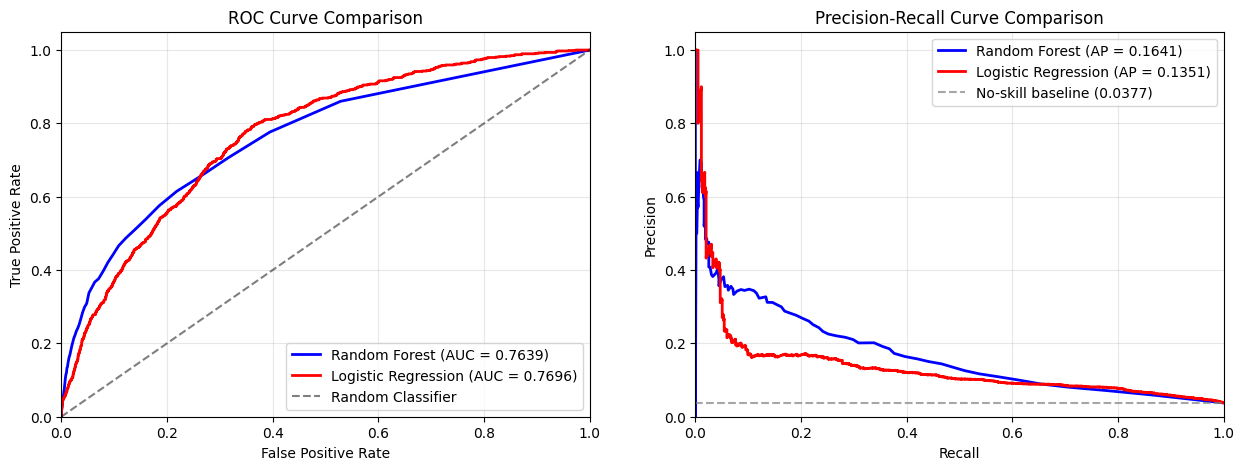

In [36]:
#Plot ROC and PR cuves side by side
plt.figure(figsize=(15, 5))
# Plot 1: ROC Comparison

plt.subplot(1,2,1)
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_lr, tpr_lr, color='red', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Plot 2: PR Comparison
plt.subplot(1,2,2)
baseline = np.sum(y_test_clf) / len(y_test_clf)
plt.plot(recall_rf, precision_rf, color='blue', lw=2, label=f'Random Forest (AP = {ap_rf:.4f})')
plt.plot(recall_lr, precision_lr, color='red', lw=2, label=f'Logistic Regression (AP = {ap_lr:.4f})')
plt.axhline(y=baseline, color='gray', linestyle='--', alpha=0.7, label=f'No-skill baseline ({baseline:.4f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

**Key Insights:**

1. **ROC analysis**:
    - LR seems to performs slightly better based on the AUC.
    - Looking at the ROC curves, RF is better in low FPR regions and LR better in high FPR regions. There is a crossing at approximately 0.35 FPR.
    - Since the curves cross and the AUC difference < 0.02 --> no clear winner based on ROC analysis
   

2. **PR Analysis:**
    - The AP of the RF is higher than the AP of LR and the difference is bigger than 0.02 --> RF is the clear winner.

3. **Detailed PR Curve Examination:**
    - RF mostly dominates LR, however in the low recall regions (smaller than 0.05),LR is dominating.
    - Overall, RF offers a better trade-off between precision and recall for most thresholds.

Based on our decision framework, we would **choose** **RF** above LR.

However, the **business context** and **application** should be taken into account. Some potential **business strategies for customer churn** could be:

1. **High-Precision Strategy**: Choose model with better precision at low recall
   - Use when campaign capacity is limited and the campaign should be as succesful as possible. This means that among the predicted churners, the detection rate shuold be high.
   - Focus on high-confidence churn predictions

2. **High-Recall Strategy**: Choose model with better recall at acceptable precision
   - Use when customer retention is critical and the correct detection of churners is crucial.
   - Accept more false positives to catch more churners

3. **Balanced Approach**: Optimize F1-score or use business cost matrix
   - Balance precision and recall based on business costs
   - Consider customer lifetime value in decision making.

#### Lift Analysis and Top Decile Lift

**Lift analysis** is especially important when you have a model built not to detect all categories but to enable more targeted actions (e.g., churn campaigns). The **Top Decile Lift (TDL)** tells you how much better your model performs compared to a random approach when contacting exactly 10% of your customer base.

The lift concept compares your model's success rate in a certain bucket against the baseline random success rate (which equals the overall churn rate).

**Note**: For the lift chart, we'll use the `sklearn-evaluation` package which provides clean, optimized functions for computing cumulative gains, lift curves, and other business-focused metrics. This is much more efficient than manual calculation and follows industry standards.

In [43]:
%pip install sklearn-evaluation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.7/108.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 9.6 MB/s eta 0:00:00


=== Top Decile Lift Analysis ===
Top-10 Decile Lift: 4.17x
Baseline churn rate: 3.8%
Model performance: 4.17x better than random targeting


<Figure size 1000x500 with 0 Axes>

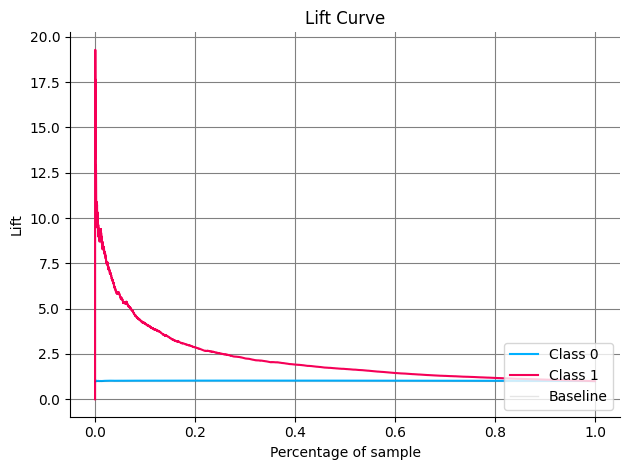

In [37]:
# Top Decile Lift Analysis using sklearn-evaluation
from sklearn_evaluation.plot import lift_curve

print("=== Top Decile Lift Analysis ===")

# Quick calculation for top decile lift
baseline_churn_rate = np.mean(y_test_clf)
top_10_percent_size = int(0.10 * len(y_test_clf))
top_decile_indices = np.argsort(y_proba)[::-1][:top_10_percent_size]
model_success_rate = np.mean(y_test_clf.iloc[top_decile_indices])
top_decile_lift = model_success_rate / baseline_churn_rate

# Display key results
print(f"Top-10 Decile Lift: {top_decile_lift:.2f}x")
print(f"Baseline churn rate: {baseline_churn_rate:.1%}")
print(f"Model performance: {top_decile_lift:.2f}x better than random targeting")

# Visualize lift curve using sklearn-evaluation
plt.figure(figsize=(10, 5))

# Convert probabilities to 2D format for sklearn-evaluation
y_proba_2d = np.column_stack([1 - y_proba, y_proba])
lift_curve(y_test_clf, y_proba_2d)

plt.tight_layout()
plt.show()

**Key Insights:**
- **Top 10% targeting** achieves **4.14× lift** over random.  
- The model consistently outperforms random selection.  
- Higher lift at top bucket indicates **excellent ranking ability**.  

#### Cumulative Gains and Additional Metrics

Beyond ROC, lift, and precision-recall analysis, several other important classification metrics provide different perspectives on model performance. We'll calculate **Cumulative Gains**, and **KS Statistic**.

Do note that the cumulative gains curve is closely related to the lift curve. For example, the lift at the top-10% is equal to the gains at the top-10% divided by 0.10.

In [38]:
# Calculate Cumulative Gains, KS Statistic
from scipy import stats
from sklearn_evaluation.plot import cumulative_gain

# Use the 2D format expected by sklearn-evaluation
# Calculate gains
actual_churners_in_top10 = np.sum(y_test_clf.iloc[top_decile_indices])
total_churners = np.sum(y_test_clf)
gains_10pct = actual_churners_in_top10 / total_churners

# KS Statistic Calculation

def calculate_ks_statistic(y_true, y_scores):
    """Calculate Kolmogorov-Smirnov statistic"""
    pos_scores = y_scores[y_true == 1]
    neg_scores = y_scores[y_true == 0]
    ks_stat, ks_pvalue = stats.ks_2samp(pos_scores, neg_scores)

    # Alternative: From ROC curve (max(TPR - FPR))
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    ks_stat_roc = np.max(tpr - fpr)
    return ks_stat, ks_stat_roc, ks_pvalue

ks_stat, ks_stat_roc, ks_pvalue = calculate_ks_statistic(y_test_clf, y_proba)

# Display results
print(f"Cumulative Gains at 10%: {gains_10pct:.4f} ({gains_10pct*100:.1f}% of churners captured)")
print(f"KS Statistic: {ks_stat_roc:.4f} (p-value: {ks_pvalue:.2e})")

Cumulative Gains at 10%: 0.4168 (41.7% of churners captured)
KS Statistic: 0.3963 (p-value: 1.01e-107)


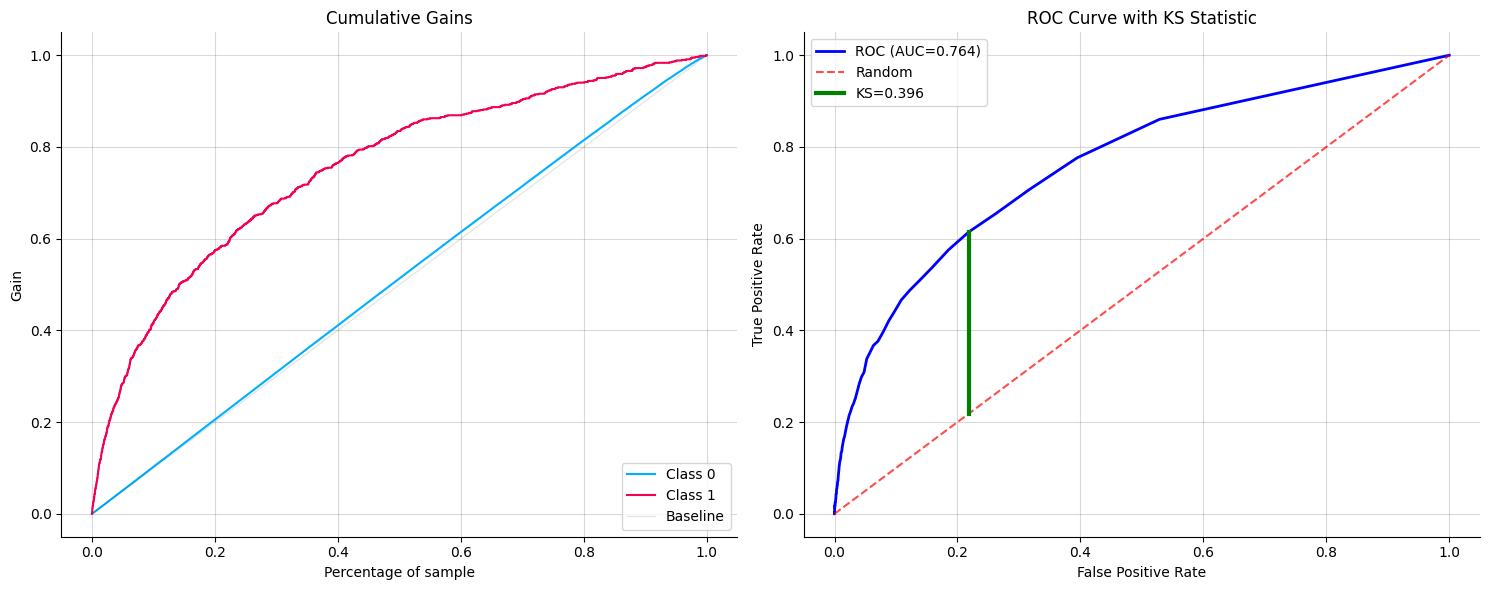

In [39]:
# Visualize metrics using sklearn-evaluation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Cumulative Gains using sklearn-evaluation
cumulative_gain(y_test_clf, y_proba_2d, ax=axes[0])
axes[0].set_title('Cumulative Gains')
axes[0].grid(True, alpha=0.3)

# Plot 2: ROC with KS Statistic
fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', alpha=0.7, label='Random')
max_ks_idx = np.argmax(tpr - fpr)
axes[1].plot([fpr[max_ks_idx], fpr[max_ks_idx]], [fpr[max_ks_idx], tpr[max_ks_idx]],
               'g-', linewidth=3, label=f'KS={ks_stat_roc:.3f}')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve with KS Statistic')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key Insights:**
- **Cumulative Gains at 10%:** 41.7% of all churners captured by targeting the top 10%.    
- **KS Statistic:** 0.396 indicates a good seperation between churner and nonchurners. Ideal values lie between 0.40 and 0.75

##### Finding the Probability Threshold at Which KS Statistic is Calculated

The **Kolmogorov-Smirnov (KS) statistic** measures the maximum separation between the cumulative distribution functions of positive and negative classes. This maximum occurs at a specific probability threshold. Let's see how we can get this threshold since this will increase our interpretation of the statistic.

In [40]:
# Get the probability threshold where KS statistic is maximized

# Calculate ROC curve components
fpr, tpr, thresholds = roc_curve(y_test_clf, y_proba)

# Find the index where KS statistic (TPR - FPR) is maximized
max_ks_idx = np.argmax(tpr - fpr)

# Get the corresponding threshold (probability)
ks_threshold = thresholds[max_ks_idx]

# Get the TPR and FPR at this threshold
ks_tpr = tpr[max_ks_idx]
ks_fpr = fpr[max_ks_idx]

# the actual KS statistic value was already computed with ks_stat_roc
# ks_value = ks_tpr - ks_fpr

print("=== KS Statistic Details ===")
print(f"KS Statistic Value: {ks_stat_roc:.4f}")
print(f"Probability Threshold: {ks_threshold:.4f}")

# You can also get predictions at this specific threshold
y_pred_ks_threshold = (y_proba >= ks_threshold).astype(int)
print(f"\nPredictions at KS threshold:")
print(f"Number predicted as positive: {np.sum(y_pred_ks_threshold)}")
print(f"Percentage predicted as positive: {np.mean(y_pred_ks_threshold)*100:.1f}%")

=== KS Statistic Details ===
KS Statistic Value: 0.3963
Probability Threshold: 0.0500

Predictions at KS threshold:
Number predicted as positive: 4876
Percentage predicted as positive: 23.4%


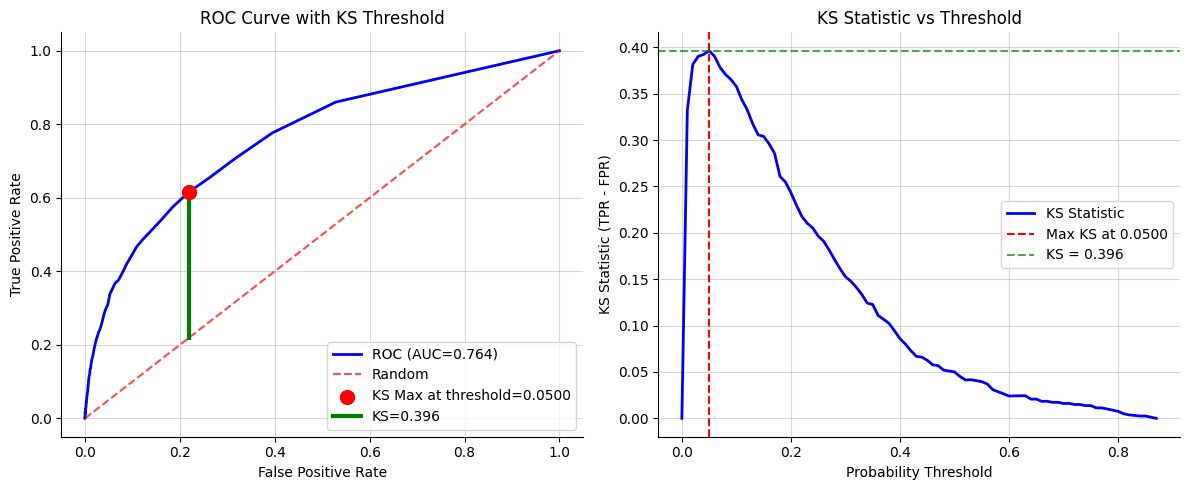

In [41]:
# Visualize the KS threshold on ROC curve
plt.figure(figsize=(12, 5))

# Plot 1: ROC Curve with KS threshold highlighted
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', alpha=0.7, label='Random')

# Highlight the KS threshold point
plt.scatter(ks_fpr, ks_tpr, color='red', s=100, zorder=5,
           label=f'KS Max at threshold={ks_threshold:.4f}')

# Draw the KS statistic line
plt.plot([ks_fpr, ks_fpr], [ks_fpr, ks_tpr], 'g-', linewidth=3,
         label=f'KS={ks_stat_roc:.3f}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with KS Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: KS statistic across all thresholds
plt.subplot(1, 2, 2)
ks_values = tpr - fpr
plt.plot(thresholds, ks_values, 'b-', linewidth=2, label='KS Statistic')
plt.axvline(x=ks_threshold, color='red', linestyle='--',
           label=f'Max KS at {ks_threshold:.4f}')
plt.axhline(y=ks_stat_roc, color='green', linestyle='--', alpha=0.7,
           label=f'KS = {ks_stat_roc:.3f}')
plt.xlabel('Probability Threshold')
plt.ylabel('KS Statistic (TPR - FPR)')
plt.title('KS Statistic vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key Insight:**  
- The KS statistic reaches its maximum value of **0.3963** at probability threshold **0.0500**.  
- This means that at this threshold, the model captures **churners 39.6% more effectively than non-churners**, achieving the **maximum separation between the two classes**.


#### Computing the KS Statistic

The **Kolmogorov-Smirnov (KS) statistic** is a key evaluation metric for binary classification models, particularly in credit scoring and customer analytics. It measures the maximum separation between the cumulative distribution functions (CDFs) of the positive and negative classes.

**Key characteristics:**
- **Range:** 0 to 1 (or 0% to 100%)
- **Interpretation:** Higher values indicate better class separation
- **Rule of thumb:** 
  - KS < 0.20: Poor separation
  - 0.20 ≤ KS < 0.40: Acceptable separation
  - 0.40 ≤ KS < 0.75: Good separation
  - KS ≥ 0.75: Excellent separation (or potential overfitting)

Let's compute the KS statistic and visualize it.

In [ ]:
from scipy.stats import ks_2samp

# Method 1: Using scipy.stats.ks_2samp
# Separate predicted probabilities for positive and negative classes
positive_probs = test_probs[y_test == 1]  # Probabilities for actual churners
negative_probs = test_probs[y_test == 0]  # Probabilities for actual non-churners

# Compute KS statistic using scipy
ks_statistic, p_value = ks_2samp(positive_probs, negative_probs)

print("=" * 80)
print("KS STATISTIC COMPUTATION")
print("=" * 80)
print(f"KS Statistic: {ks_statistic:.4f} ({ks_statistic*100:.2f}%)")
print(f"P-value: {p_value:.6f}")
print(f"\nInterpretation:")
if ks_statistic < 0.20:
    interpretation = "Poor separation between classes"
elif ks_statistic < 0.40:
    interpretation = "Acceptable separation between classes"
elif ks_statistic < 0.75:
    interpretation = "Good separation between classes"
else:
    interpretation = "Excellent separation (check for overfitting)"
print(f"  {interpretation}")

print(f"\nClass Distribution:")
print(f"  Positive class (churners): {len(positive_probs)} samples")
print(f"  Negative class (non-churners): {len(negative_probs)} samples")

In [ ]:
# Method 2: Computing KS from ROC curve (TPR - FPR)
# This method also identifies the threshold at which KS is maximized

from sklearn.metrics import roc_curve

# Calculate ROC curve
fpr_ks, tpr_ks, thresholds_ks = roc_curve(y_test, test_probs)

# KS statistic is the maximum difference between TPR and FPR
ks_values = tpr_ks - fpr_ks
ks_stat_roc = np.max(ks_values)
ks_idx = np.argmax(ks_values)

# Get the optimal threshold
optimal_threshold = thresholds_ks[ks_idx]
optimal_tpr = tpr_ks[ks_idx]
optimal_fpr = fpr_ks[ks_idx]

print("\n" + "=" * 80)
print("KS STATISTIC FROM ROC CURVE")
print("=" * 80)
print(f"KS Statistic: {ks_stat_roc:.4f} ({ks_stat_roc*100:.2f}%)")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"  - True Positive Rate at threshold: {optimal_tpr:.4f} ({optimal_tpr*100:.2f}%)")
print(f"  - False Positive Rate at threshold: {optimal_fpr:.4f} ({optimal_fpr*100:.2f}%)")

# Classification at optimal threshold
y_pred_optimal = (test_probs >= optimal_threshold).astype(int)
print(f"\nPredictions at optimal KS threshold:")
print(f"  Predicted positive: {y_pred_optimal.sum()} ({y_pred_optimal.mean()*100:.2f}%)")
print(f"  Predicted negative: {(1-y_pred_optimal).sum()} ({(1-y_pred_optimal.mean())*100:.2f}%)")

In [ ]:
# Visualize the KS Statistic

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Cumulative Distribution Functions (CDFs)
axes[0].hist(negative_probs, bins=50, alpha=0.6, label='Non-churners', 
             cumulative=True, density=True, color='blue', histtype='step', linewidth=2)
axes[0].hist(positive_probs, bins=50, alpha=0.6, label='Churners', 
             cumulative=True, density=True, color='red', histtype='step', linewidth=2)
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Cumulative Probability')
axes[0].set_title('Cumulative Distribution Functions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'KS = {ks_statistic:.4f}', 
             transform=axes[0].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: ROC Curve with KS highlighted
axes[1].plot(fpr_ks, tpr_ks, 'b-', linewidth=2, label=f'ROC Curve')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
# Highlight KS point
axes[1].scatter([optimal_fpr], [optimal_tpr], color='red', s=200, zorder=5, 
                label=f'KS={ks_stat_roc:.4f}')
# Draw KS distance line
axes[1].plot([optimal_fpr, optimal_fpr], [optimal_fpr, optimal_tpr], 
             'g-', linewidth=3, label='KS Distance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve with KS Statistic')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: KS statistic across thresholds
axes[2].plot(thresholds_ks, ks_values, 'b-', linewidth=2)
axes[2].axvline(x=optimal_threshold, color='red', linestyle='--', linewidth=2,
                label=f'Optimal threshold = {optimal_threshold:.4f}')
axes[2].axhline(y=ks_stat_roc, color='green', linestyle='--', linewidth=2, alpha=0.7,
                label=f'Max KS = {ks_stat_roc:.4f}')
axes[2].scatter([optimal_threshold], [ks_stat_roc], color='red', s=200, zorder=5)
axes[2].set_xlabel('Probability Threshold')
axes[2].set_ylabel('KS Statistic (TPR - FPR)')
axes[2].set_title('KS Statistic vs Threshold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key Insights:**

The visualizations above show three perspectives on the KS statistic:

1. **Cumulative Distribution Functions (Left)**: Shows how the predicted probabilities are distributed differently for churners vs non-churners. The maximum vertical distance between these curves is the KS statistic.

2. **ROC Curve (Middle)**: The KS statistic is the maximum vertical distance between the ROC curve and the diagonal (shown as the green line). This occurs at the red point, representing the optimal discrimination threshold.

3. **KS vs Threshold (Right)**: Shows how the KS statistic changes across different probability thresholds. The peak indicates the threshold that maximizes class separation.

**Practical interpretation:**
- At the optimal threshold, the model achieves maximum separation between churners and non-churners
- This threshold can be used for business decisions when you need to balance sensitivity and specificity
- A higher KS statistic indicates better model discrimination ability